In [1]:
pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 36.0 MB/s eta 0:00:00


In [2]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)


Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 107 (delta 39), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 2.42 MiB | 14.15 MiB/s, done.
Resolving deltas: 100% (39/39), done.
Loading pre-computed data from GitHub repository...
Generating Figure...


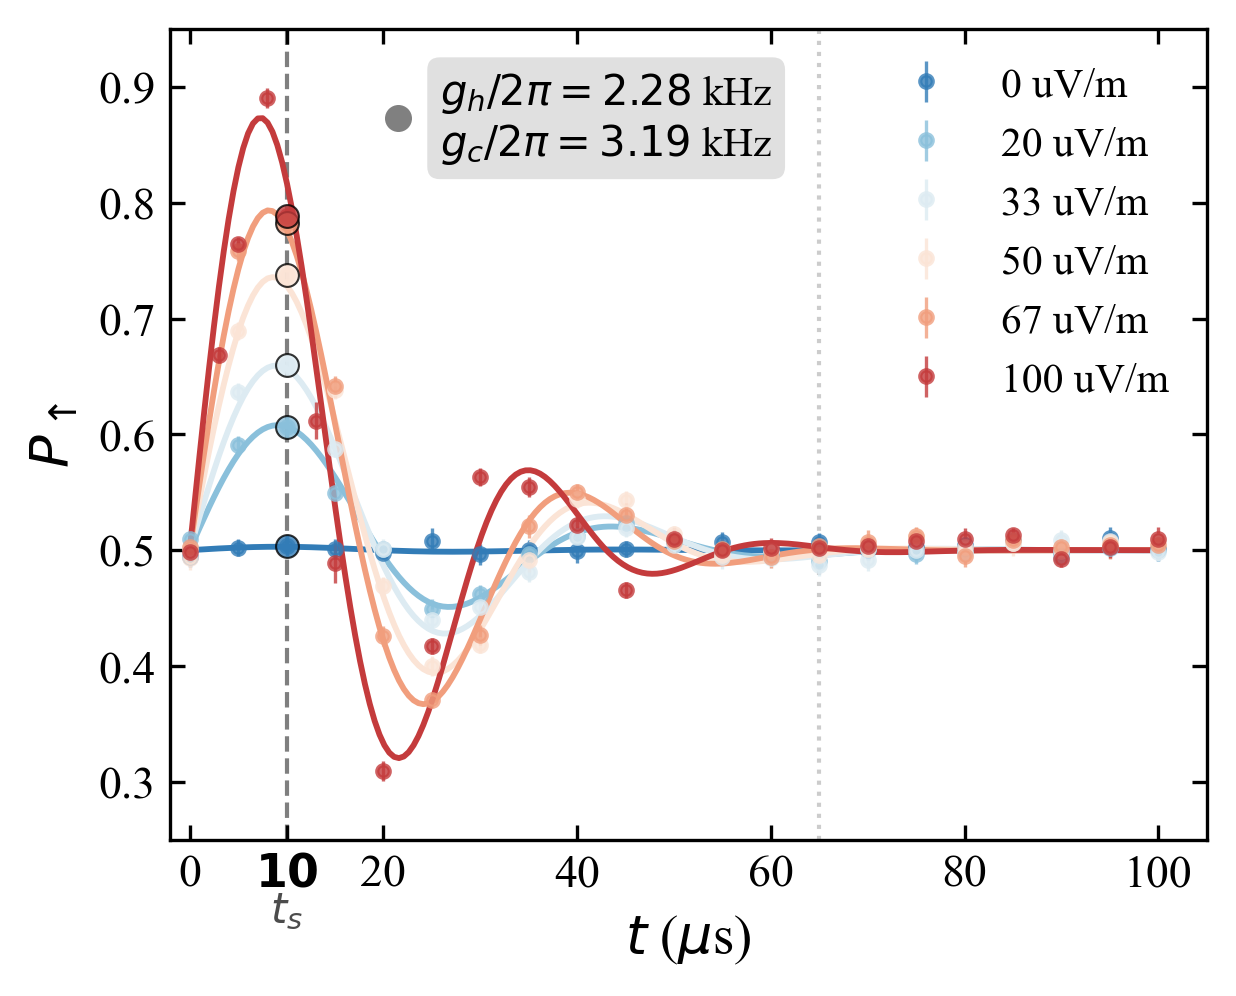

Figure saved as 'Fig3_Subplot_TimeEvolution_B22.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.

Label        | Fit E (uV/m)         | Steady <n>   | P_up @ 10us (Exp)    | Diff
--------------------------------------------------------------------------------------------------------------
0 uV/m       |    0.55 ± 1.02   | 5.15         | 0.5040               | +0.0000
20 uV/m      |   20.48 ± 1.13   | 5.35         | 0.6064               | +0.0000
33 uV/m      |   30.80 ± 1.17   | 5.61         | 0.6603               | +0.0000
50 uV/m      |   47.63 ± 1.31   | 6.26         | 0.7379               | +0.0000
67 uV/m      |   62.47 ± 1.25   | 7.07         | 0.7829               | +0.0000
100 uV/m     |   89.53 ± 0.50   | 9.19         | 0.7885               | +0.0000


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.optimize import curve_fit
import os
from datetime import datetime
from google.colab import files

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP simulation and curve fitting
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git
!unzip -o -q Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data.zip -d ./Fig3_data/

# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Global Style Settings ==================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.0,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 300
})

# ================== 3. Physics Parameters ==================
N = 60
eta = 0.114
Omega_r, Omega_b = 2*np.pi*28e3, 2*np.pi*20e3
gammar, gammab = 150e3, 15e3
Omega_eff = 2*np.pi*50e3
phi_drive = 0
dphi = 2*np.pi

hbar, q = 1.054571817e-34, 1.602176634e-19
m = 40*1.66053906660e-27
omega_trap = 2*np.pi*676.35e3
x0 = np.sqrt(hbar/(2*m*omega_trap))

t_evol = 5.7e-3
nbar_init = 0.3
t0_us = 10
T_MAX_FIT = 65.0  # Strict physical truncation: only fit data points with t < 65 us

# ================== 4. Operators and Hamiltonian ==================
a = destroy(N)
I_m, I_i = qeye(N), qeye(3)
g, er, eb = basis(3,0), basis(3,1), basis(3,2)

sig_rg_tot = tensor(er*g.dag(), I_m)
sig_gr_tot = tensor(g*er.dag(), I_m)
sig_bg_tot = tensor(eb*g.dag(), I_m)
sig_gb_tot = tensor(g*eb.dag(), I_m)
a_tot, adag_tot = tensor(I_i, a), tensor(I_i, a.dag())

H0 = (0.5*1j*Omega_r*eta*(sig_gr_tot*adag_tot - sig_rg_tot*a_tot) +
      0.5*1j*Omega_b*eta*(sig_bg_tot*adag_tot - sig_gb_tot*a_tot))

c_ops = [np.sqrt(gammar)*sig_gr_tot, np.sqrt(gammab)*sig_gb_tot]
rho0 = tensor(g*g.dag(), thermal_dm(N, nbar_init))

# ================== 5. Fitting Model Functions ==================
rho_cache = {}

def get_rho_m(E_uV):
    key = round(float(E_uV), 8)
    if key in rho_cache: return rho_cache[key]
    E = E_uV * 1e-6
    H_drive = tensor(I_i, -(E*q*x0/(2j*hbar)) * (a*np.exp(1j*phi_drive) - a.dag()*np.exp(-1j*phi_drive)))
    sol = mesolve(H0 + H_drive, rho0, [0, t_evol], c_ops=c_ops, e_ops=[], options={'nsteps': 20000, 'max_step': 1e-5, 'atol': 1e-9, 'rtol': 1e-8, 'method': 'bdf'})
    rho_m = ptrace(sol.states[-1], 1)
    rho_cache[key] = rho_m
    return rho_m

def P_up_theory_scaled(tlist, E_uV):
    rho_m = get_rho_m(E_uV)
    P_list = []
    for t in tlist:
        beta = -1j * eta * Omega_eff * t * np.exp(-1j*dphi/2)
        D = displace(N, beta)
        chi = (D * rho_m).tr()
        P_list.append((1 - np.imag(chi)) / 2)
    return np.array(P_list)

# ================== 6. Data Compute or Load ==================
# Note: Match the exact filename uploaded to GitHub
npz_filename = 'time_evolution_data_B22.npz'

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP simulation and fitting...")

    base_path = "./Fig3_data"
    data_sets = {
        "0 uV/m":   f"{base_path}/B22_dynamic/exp",
        "20 uV/m":  f"{base_path}/B22_20uV0phi_dynamic/exp",
        "33 uV/m":  f"{base_path}/B22_33uV0phi_dynamic/exp",
        "50 uV/m":  f"{base_path}/B22_50uV0phi_dynamic/exp",
        "67 uV/m":  f"{base_path}/B22_67uV0phi_dynamic/exp",
        "100 uV/m": f"{base_path}/B22_100uV0phi_dynamic/exp",
    }

    results = {}
    save_data = {
        'labels': sorted(data_sets.keys(), key=lambda x: float(x.split()[0])),
        't_us_all': {}, 'P_mean_all': {}, 'P_sem_all': {},
        'fit_results': {}, 'fit_curves': {},
        'params': {'T_MAX_FIT': T_MAX_FIT, 't0_us': t0_us, 'eta': eta}
    }

    labels_sorted = save_data['labels']

    for i, label in enumerate(labels_sorted):
        print(f"Processing {label}...")
        folder = data_sets[label]
        rho_cache.clear()

        if not os.path.exists(folder):
            print(f"Folder not found: {folder}")
            continue

        files = [f for f in os.listdir(folder) if f.endswith(".txt")]
        files_sorted = sorted(files, key=lambda x: float(x.replace(".txt","")))
        t_us_list = np.array([float(f.replace(".txt","")) for f in files_sorted])
        t_exp = t_us_list * 1e-6

        P_mean_list, P_sem_list = [], []
        for f in files_sorted:
            data = np.loadtxt(os.path.join(folder, f))
            P_mean_list.append(np.mean(data))
            P_sem_list.append(np.std(data, ddof=1)/np.sqrt(len(data)))
        P_mean = np.array(P_mean_list)
        P_sem = np.array(P_sem_list)

        save_data['t_us_all'][label] = t_us_list
        save_data['P_mean_all'][label] = P_mean
        save_data['P_sem_all'][label] = P_sem

        fit_mask = t_us_list < T_MAX_FIT
        t_exp_fit = t_exp[fit_mask]
        P_mean_fit = P_mean[fit_mask]
        fit_weights = P_sem[fit_mask].copy()

        nominal_E = float(label.split()[0])
        try:
            popt, pcov = curve_fit(P_up_theory_scaled, t_exp_fit, P_mean_fit, sigma=fit_weights, absolute_sigma=True, p0=[nominal_E], bounds=(-5, 200), ftol=1e-10, xtol=1e-10)
            E_fit, E_err = popt[0], np.sqrt(pcov[0,0])
        except Exception as e:
            print(f"Fit failed for {label}: {e}")
            E_fit, E_err = nominal_E, 0.0

        rho_f = get_rho_m(E_fit)
        n_steady = expect(a.dag()*a, rho_f).real
        results[label] = {"E_fit": E_fit, "E_err": E_err, "nbar": n_steady}
        save_data['fit_results'][label] = results[label]

        t_dense = np.linspace(0, 100e-6, 200)
        P_dense = P_up_theory_scaled(t_dense, E_fit)
        save_data['fit_curves'][label] = {'t_us': t_dense * 1e6, 'P': P_dense}

    np.savez(npz_filename, **save_data)
    print(f"Data saved to {npz_filename}")

else:
    print(f"Loading pre-computed data from GitHub repository...")
    # Point to the absolute path inside the cloned GitHub repository
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/{npz_filename}'

    if os.path.exists(npz_path):
        data = np.load(npz_path, allow_pickle=True)
        labels = data['labels'].tolist()
        t_us_all = data['t_us_all'].item()
        P_mean_all = data['P_mean_all'].item()
        P_sem_all = data['P_sem_all'].item()
        fit_curves = data['fit_curves'].item()
        results_dict = data['fit_results'].item()
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 7. Plotting ==================
print("Generating Figure...")
fig, ax = plt.subplots(figsize=(4.0, 3.2))

# Color palette matching Fig. 1 (RdBu_r)
n_colors = len(labels)
cmap = plt.get_cmap('RdBu_r')
positions = np.linspace(0.15, 0.85, n_colors)
vline_colors = [cmap(pos) for pos in positions]

for i, label in enumerate(labels):
    color = vline_colors[i]
    t_us = t_us_all[label]
    P_mean = P_mean_all[label]
    P_sem = P_sem_all[label]

    ax.errorbar(t_us, P_mean, yerr=P_sem, fmt='o', color=color, markersize=3.0, elinewidth=0.8, capsize=0, alpha=0.8, label=label)

    # Highlight the data point at t=10 us
    idx_10 = np.where(np.isclose(t_us, 10, atol=0.5))[0]
    if len(idx_10) > 0:
        ax.scatter(t_us[idx_10], P_mean[idx_10], color=color, s=30, marker='o', edgecolor='k', linewidth=0.5, facecolor=color, zorder=5, alpha=0.8)

    curve = fit_curves[label]
    ax.plot(curve['t_us'], curve['P'], '-', color=color, lw=1.4)

# Vertical markers
ax.axvline(x=10, color='black', linestyle='--', linewidth=1.0, alpha=0.5, zorder=0)
ax.text(10, ax.get_ylim()[0] - 0.1, '$t_s$', ha='center', va='bottom', fontsize=10, color='black', alpha=0.7)
ax.axvline(x=65, color='gray', linestyle=':', linewidth=1.0, alpha=0.4, zorder=0)

# Parameter annotation box
ax.scatter(0.22, 0.89, s=30, color='gray', marker='o', transform=ax.transAxes, clip_on=False)
param_text = r"$g_h/2\pi = 2.28$ kHz" + "\n" + r"$g_c/2\pi = 3.19$ kHz"
ax.text(0.26, 0.95, param_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', fontfamily='serif', linespacing=1.2, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', edgecolor='none', alpha=0.7))

# Axis labels and ranges
ax.set_xlabel(r"$t$ ($\mu$s)")
ax.set_ylabel(r"$P_{\uparrow}$")
ax.set_xticks([0, 10, 20, 40, 60, 80, 100])
ax.set_xticklabels(['0', r'$\mathbf{10}$', '20', '40', '60', '80', '100'], fontsize=11)
ax.set_xlim(-2, 105)
ax.set_ylim(0.25, 0.95)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout(pad=0.2)

# ================== 8. Save and Download ==================
pdf_name = 'Fig3_Subplot_TimeEvolution_B22.pdf'
plt.savefig(pdf_name, dpi=600, bbox_inches='tight')
plt.show()
print(f"Figure saved as '{pdf_name}'")

try:
    files.download(pdf_name)
    print("PDF download triggered.")
except Exception as e:
    print("Automatic download failed. Download manually from file browser.")

# ================== 9. Terminal Table Output ==================
print("\n" + "="*110)
print(f"{'Label':<12} | {'Fit E (uV/m)':<20} | {'Steady <n>':<12} | {'P_up @ 10us (Exp)':<20} | {'Diff'}")
print("-"*110)

# Use explicit if-else to retrieve the correct dictionary, avoiding scope issues
if RECOMPUTE_DATA:
    res_dict = save_data['fit_results']
else:
    res_dict = results_dict

for label in labels:
    if label in res_dict:
        res = res_dict[label]
        exp_data = P_mean_all[label]
        t_10 = np.where(np.isclose(t_us_all[label], 10, atol=0.5))[0]
        p10_exp = exp_data[t_10[0]] if len(t_10) > 0 else 0

        # Only calculate the difference if data was recomputed
        diff = 0.0
        if RECOMPUTE_DATA:
            diff = p10_exp - P_up_theory_scaled([t0_us*1e-6], res['E_fit'])[0]

        print(f"{label:<12} | {res['E_fit']:>7.2f} ± {res['E_err']:<6.2f} | {res['nbar']:<12.2f} | {p10_exp:<20.4f} | {diff:>+7.4f}")
print("="*110)

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 107 (delta 39), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 2.42 MiB | 14.92 MiB/s, done.
Resolving deltas: 100% (39/39), done.
unzip:  cannot find or open Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B46.zip, Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B46.zip.zip or Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B46.zip.ZIP.
Loading pre-computed data from GitHub repository...
Generating Figure...


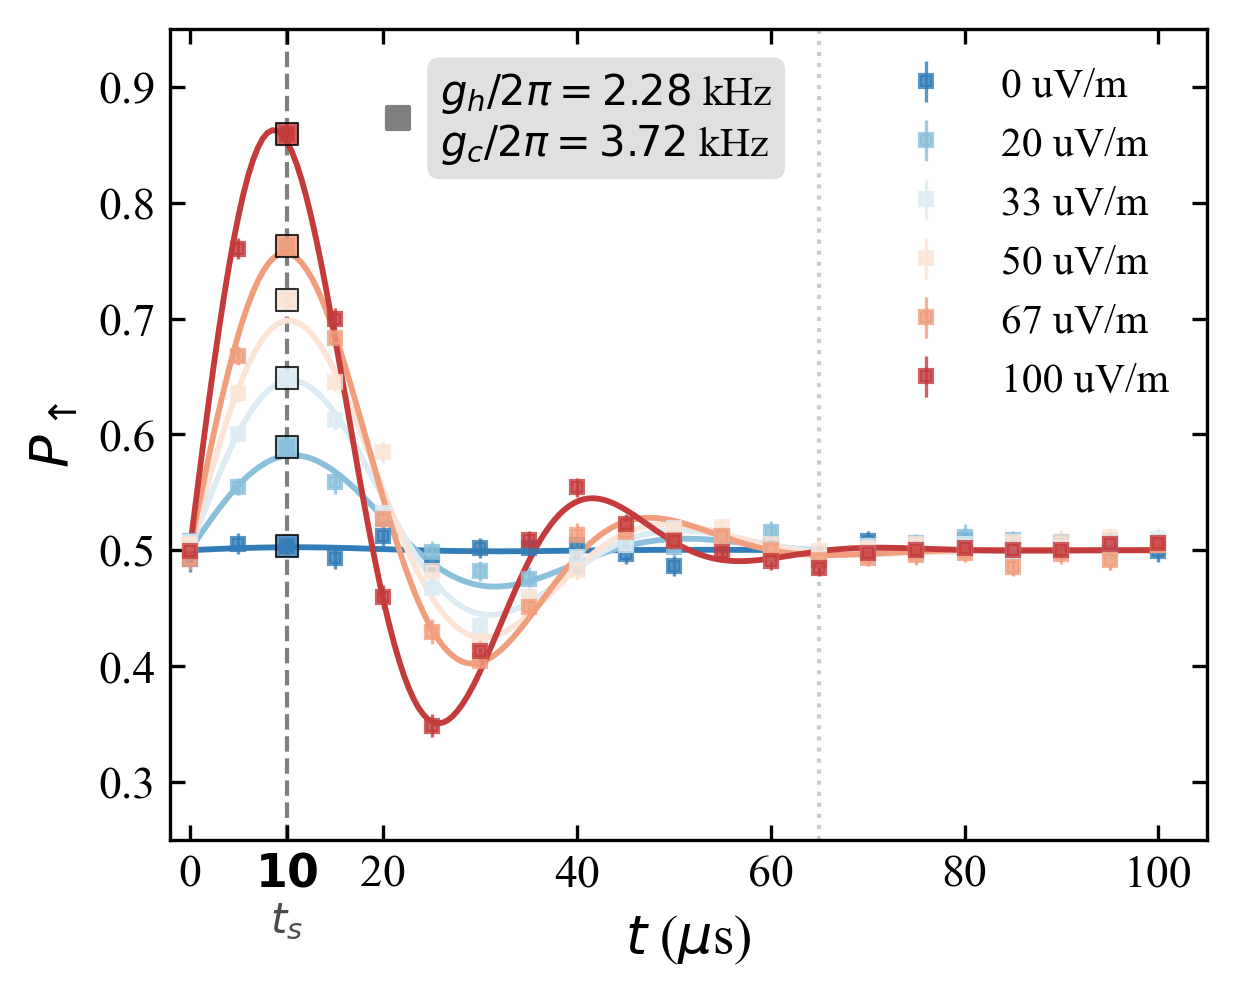

Figure saved as 'Fig3_Subplot_TimeEvolution_B46.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.

Label        | Fit E (uV/m)         | Steady <n>   | P_up @ 10us (Exp)    | Diff
--------------------------------------------------------------------------------------------------------------
0 uV/m       |    0.57 ± 1.12   | 3.57         | 0.5034               | +0.0000
20 uV/m      |   18.66 ± 1.07   | 3.66         | 0.5887               | +0.0000
33 uV/m      |   33.95 ± 0.93   | 3.87         | 0.6487               | +0.0000
50 uV/m      |   47.04 ± 1.45   | 4.14         | 0.7158               | +0.0000
67 uV/m      |   63.29 ± 1.41   | 4.61         | 0.7625               | +0.0000
100 uV/m     |  101.28 ± 1.50   | 6.32         | 0.8600               | +0.0000


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.optimize import curve_fit
import os
from datetime import datetime
from google.colab import files

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP simulation and curve fitting
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# Note: Adjust the zip filename if your B46 data is packed differently
!unzip -o -q Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B46.zip -d ./Fig3_data_B46/

# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Global Style Settings ==================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.0,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 300
})

# ================== 3. Physics Parameters (B46 Dataset) ==================
N = 60
eta = 0.114
# IMPORTANT: Omega_r differs from the B22 dataset
Omega_r, Omega_b = 2*np.pi*32.6e3, 2*np.pi*20e3
gammar, gammab = 150e3, 15e3
Omega_eff = 2*np.pi*50e3
phi_drive = 0
dphi = 2*np.pi

hbar, q = 1.054571817e-34, 1.602176634e-19
m = 40*1.66053906660e-27
omega_trap = 2*np.pi*676.35e3
x0 = np.sqrt(hbar/(2*m*omega_trap))

t_evol = 5.7e-3
nbar_init = 0.3
t0_us = 10
T_MAX_FIT = 65.0  # Strict physical truncation: only fit data points with t < 65 us

# ================== 4. Operators and Hamiltonian ==================
a = destroy(N)
I_m, I_i = qeye(N), qeye(3)
g, er, eb = basis(3,0), basis(3,1), basis(3,2)

sig_rg_tot = tensor(er*g.dag(), I_m)
sig_gr_tot = tensor(g*er.dag(), I_m)
sig_bg_tot = tensor(eb*g.dag(), I_m)
sig_gb_tot = tensor(g*eb.dag(), I_m)
a_tot, adag_tot = tensor(I_i, a), tensor(I_i, a.dag())

H0 = (0.5*1j*Omega_r*eta*(sig_gr_tot*adag_tot - sig_rg_tot*a_tot) +
      0.5*1j*Omega_b*eta*(sig_bg_tot*adag_tot - sig_gb_tot*a_tot))

c_ops = [np.sqrt(gammar)*sig_gr_tot, np.sqrt(gammab)*sig_gb_tot]
rho0 = tensor(g*g.dag(), thermal_dm(N, nbar_init))

# ================== 5. Fitting Model Functions ==================
rho_cache = {}

def get_rho_m(E_uV):
    key = round(float(E_uV), 8)
    if key in rho_cache: return rho_cache[key]
    E = E_uV * 1e-6
    H_drive = tensor(I_i, -(E*q*x0/(2j*hbar)) * (a*np.exp(1j*phi_drive) - a.dag()*np.exp(-1j*phi_drive)))
    sol = mesolve(H0 + H_drive, rho0, [0, t_evol], c_ops=c_ops, e_ops=[], options={'nsteps': 20000, 'max_step': 1e-5, 'atol': 1e-9, 'rtol': 1e-8, 'method': 'bdf'})
    rho_m = ptrace(sol.states[-1], 1)
    rho_cache[key] = rho_m
    return rho_m

def P_up_theory_scaled(tlist, E_uV):
    rho_m = get_rho_m(E_uV)
    P_list = []
    for t in tlist:
        beta = -1j * eta * Omega_eff * t * np.exp(-1j*dphi/2)
        D = displace(N, beta)
        chi = (D * rho_m).tr()
        P_list.append((1 - np.imag(chi)) / 2)
    return np.array(P_list)

# ================== 6. Data Compute or Load ==================
npz_filename = 'time_evolution_data_B46.npz'

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP simulation and fitting...")

    base_path = "./Fig3_data_B46"
    data_sets = {
        "0 uV/m":   f"{base_path}/B46/exp",
        "20 uV/m":  f"{base_path}/B46_20uV0phi/exp",
        "33 uV/m":  f"{base_path}/B46_33uV0phi/exp",
        "50 uV/m":  f"{base_path}/B46_50uV0phi/exp",
        "67 uV/m":  f"{base_path}/B46_67uV0phi/exp",
        "100 uV/m": f"{base_path}/B46_100uV0phi/exp",
    }

    results = {}
    save_data = {
        'labels': sorted(data_sets.keys(), key=lambda x: float(x.split()[0])),
        't_us_all': {}, 'P_mean_all': {}, 'P_sem_all': {},
        'fit_results': {}, 'fit_curves': {},
        'params': {'T_MAX_FIT': T_MAX_FIT, 't0_us': t0_us, 'eta': eta}
    }

    labels_sorted = save_data['labels']

    for i, label in enumerate(labels_sorted):
        print(f"Processing {label}...")
        folder = data_sets[label]
        rho_cache.clear()

        if not os.path.exists(folder):
            print(f"Folder not found: {folder}")
            continue

        files = [f for f in os.listdir(folder) if f.endswith(".txt")]
        files_sorted = sorted(files, key=lambda x: float(x.replace(".txt","")))
        t_us_list = np.array([float(f.replace(".txt","")) for f in files_sorted])
        t_exp = t_us_list * 1e-6

        P_mean_list, P_sem_list = [], []
        for f in files_sorted:
            data = np.loadtxt(os.path.join(folder, f))
            P_mean_list.append(np.mean(data))
            P_sem_list.append(np.std(data, ddof=1)/np.sqrt(len(data)))
        P_mean = np.array(P_mean_list)
        P_sem = np.array(P_sem_list)

        save_data['t_us_all'][label] = t_us_list
        save_data['P_mean_all'][label] = P_mean
        save_data['P_sem_all'][label] = P_sem

        fit_mask = t_us_list < T_MAX_FIT
        t_exp_fit = t_exp[fit_mask]
        P_mean_fit = P_mean[fit_mask]
        fit_weights = P_sem[fit_mask].copy()

        nominal_E = float(label.split()[0])
        try:
            popt, pcov = curve_fit(P_up_theory_scaled, t_exp_fit, P_mean_fit, sigma=fit_weights, absolute_sigma=True, p0=[nominal_E], bounds=(-5, 200), ftol=1e-10, xtol=1e-10)
            E_fit, E_err = popt[0], np.sqrt(pcov[0,0])
        except Exception as e:
            print(f"Fit failed for {label}: {e}")
            E_fit, E_err = nominal_E, 0.0

        rho_f = get_rho_m(E_fit)
        n_steady = expect(a.dag()*a, rho_f).real
        results[label] = {"E_fit": E_fit, "E_err": E_err, "nbar": n_steady}
        save_data['fit_results'][label] = results[label]

        t_dense = np.linspace(0, 100e-6, 200)
        P_dense = P_up_theory_scaled(t_dense, E_fit)
        save_data['fit_curves'][label] = {'t_us': t_dense * 1e6, 'P': P_dense}

    np.savez(npz_filename, **save_data)
    print(f"Data saved to {npz_filename}")

else:
    print(f"Loading pre-computed data from GitHub repository...")
    # Point to the absolute path inside the cloned GitHub repository
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/{npz_filename}'

    if os.path.exists(npz_path):
        data = np.load(npz_path, allow_pickle=True)
        labels = data['labels'].tolist()
        t_us_all = data['t_us_all'].item()
        P_mean_all = data['P_mean_all'].item()
        P_sem_all = data['P_sem_all'].item()
        fit_curves = data['fit_curves'].item()
        results_dict = data['fit_results'].item()
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 7. Plotting (B46 Style: Square Markers) ==================
print("Generating Figure...")
fig, ax = plt.subplots(figsize=(4.0, 3.2))

# Color palette matching Fig. 1 (RdBu_r)
n_colors = len(labels)
cmap = plt.get_cmap('RdBu_r')
positions = np.linspace(0.15, 0.85, n_colors)
vline_colors = [cmap(pos) for pos in positions]

for i, label in enumerate(labels):
    color = vline_colors[i]
    t_us = t_us_all[label]
    P_mean = P_mean_all[label]
    P_sem = P_sem_all[label]

    # Use square markers ('s') for B46 dataset
    ax.errorbar(t_us, P_mean, yerr=P_sem, fmt='s', color=color, markersize=3.0, elinewidth=0.8, capsize=0, alpha=0.8, label=label)

    # Highlight the data point at t=10 us with black edge
    idx_10 = np.where(np.isclose(t_us, 10, atol=0.5))[0]
    if len(idx_10) > 0:
        ax.scatter(t_us[idx_10], P_mean[idx_10], color=color, s=30, marker='s', edgecolor='k', linewidth=0.5, facecolor=color, zorder=5, alpha=0.8)

    curve = fit_curves[label]
    ax.plot(curve['t_us'], curve['P'], '-', color=color, lw=1.4)

# Vertical markers
ax.axvline(x=10, color='black', linestyle='--', linewidth=1.0, alpha=0.5, zorder=0)
y_pos = ax.get_ylim()[0] - 0.15
ax.text(10, y_pos, '$t_s$', ha='center', va='bottom', fontsize=10, color='black', alpha=0.7)
ax.axvline(x=65, color='gray', linestyle=':', linewidth=1.0, alpha=0.4, zorder=0)

# Parameter annotation box (B46 specific parameters)
ax.scatter(0.22, 0.89, s=30, color='gray', marker='s', transform=ax.transAxes, clip_on=False)
param_text = r"$g_h/2\pi = 2.28$ kHz" + "\n" + r"$g_c/2\pi = 3.72$ kHz"
ax.text(0.26, 0.95, param_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', fontfamily='serif', linespacing=1.2, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', edgecolor='none', alpha=0.7))

# Axis labels and ranges
ax.set_xlabel(r"$t$ ($\mu$s)")
ax.set_ylabel(r"$P_{\uparrow}$")
ax.set_xticks([0, 10, 20, 40, 60, 80, 100])
ax.set_xticklabels(['0', r'$\mathbf{10}$', '20', '40', '60', '80', '100'], fontsize=11)
ax.set_xlim(-2, 105)
ax.set_ylim(0.25, 0.95)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout(pad=0.2)

# ================== 8. Save and Download ==================
pdf_name = 'Fig3_Subplot_TimeEvolution_B46.pdf'
plt.savefig(pdf_name, dpi=600, bbox_inches='tight')
plt.show()
print(f"Figure saved as '{pdf_name}'")

try:
    files.download(pdf_name)
    print("PDF download triggered.")
except Exception as e:
    print("Automatic download failed. Download manually from file browser.")

# ================== 9. Terminal Table Output ==================
print("\n" + "="*110)
print(f"{'Label':<12} | {'Fit E (uV/m)':<20} | {'Steady <n>':<12} | {'P_up @ 10us (Exp)':<20} | {'Diff'}")
print("-"*110)

if RECOMPUTE_DATA:
    res_dict = save_data['fit_results']
else:
    res_dict = results_dict

for label in labels:
    if label in res_dict:
        res = res_dict[label]
        exp_data = P_mean_all[label]
        t_10 = np.where(np.isclose(t_us_all[label], 10, atol=0.5))[0]
        p10_exp = exp_data[t_10[0]] if len(t_10) > 0 else 0

        diff = 0.0
        if RECOMPUTE_DATA:
            diff = p10_exp - P_up_theory_scaled([t0_us*1e-6], res['E_fit'])[0]

        print(f"{label:<12} | {res['E_fit']:>7.2f} ± {res['E_err']:<6.2f} | {res['nbar']:<12.2f} | {p10_exp:<20.4f} | {diff:>+7.4f}")
print("="*110)

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 107 (delta 39), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 2.42 MiB | 23.58 MiB/s, done.
Resolving deltas: 100% (39/39), done.
unzip:  cannot find or open Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B42.zip, Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B42.zip.zip or Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B42.zip.ZIP.
Loading pre-computed data from GitHub repository...
Generating Figure...


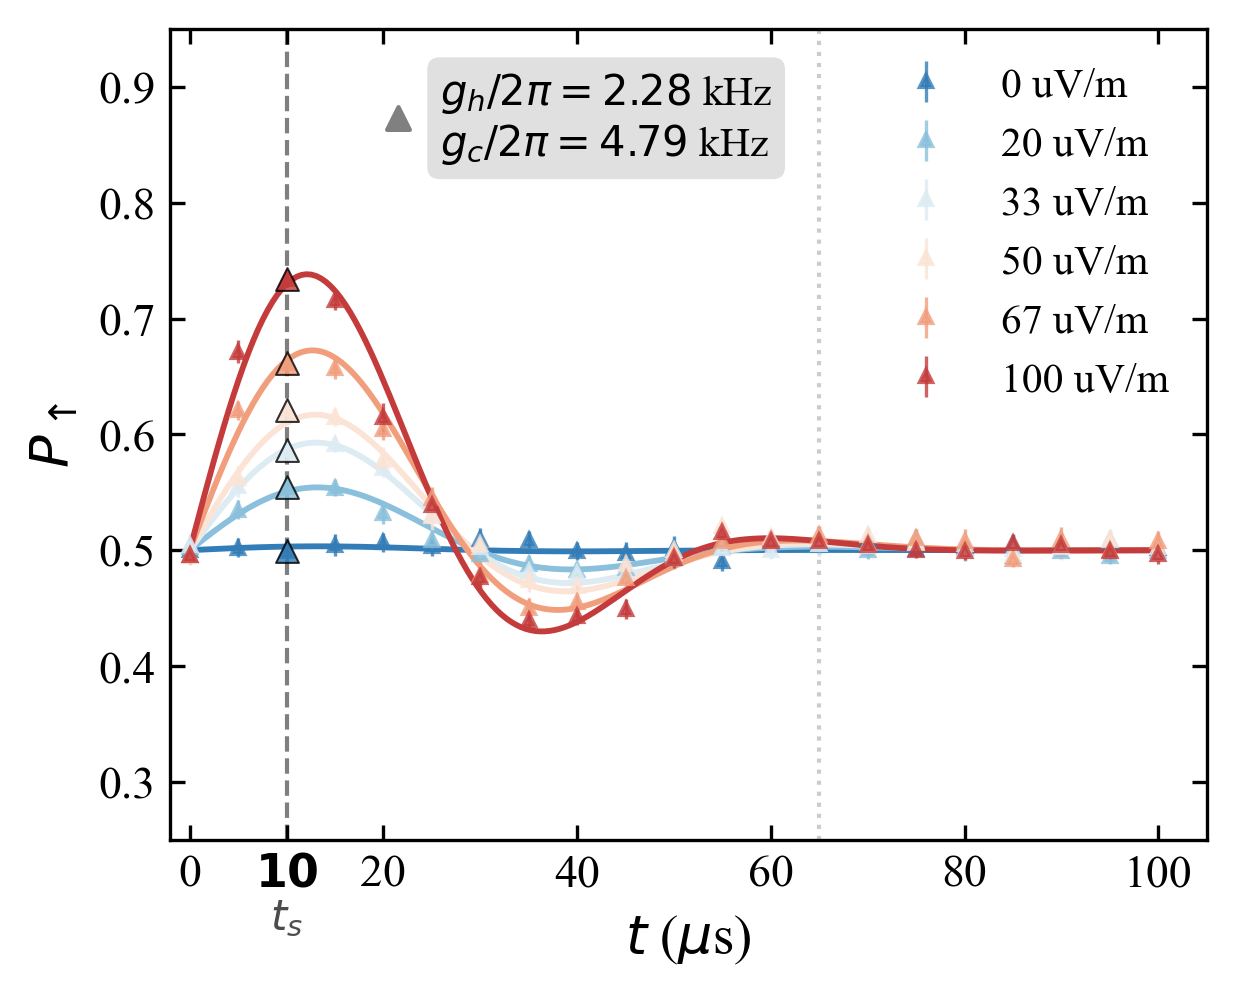

Figure saved as 'Fig3_Subplot_TimeEvolution_B42.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.

Label        | Fit E (uV/m)         | Steady <n>   | P_up @ 10us (Exp)    | Diff
--------------------------------------------------------------------------------------------------------------
0 uV/m       |    1.24 ± 1.91   | 2.00         | 0.4997               | +0.0000
20 uV/m      |   20.20 ± 1.82   | 2.03         | 0.5549               | +0.0000
33 uV/m      |   34.80 ± 1.75   | 2.09         | 0.5863               | +0.0000
50 uV/m      |   44.08 ± 2.05   | 2.14         | 0.6212               | +0.0000
67 uV/m      |   66.18 ± 2.26   | 2.32         | 0.6621               | +0.0000
100 uV/m     |   94.44 ± 2.20   | 2.66         | 0.7343               | +0.0000


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.optimize import curve_fit
import os
from datetime import datetime
from google.colab import files

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP simulation and curve fitting
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# Note: Adjust the zip filename if your B42 data is packed differently
!unzip -o -q Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B42.zip -d ./Fig3_data_B42/

# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Global Style Settings ==================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.0,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 300
})

# ================== 3. Physics Parameters (B42 Dataset) ==================
N = 60
eta = 0.114
# IMPORTANT: Omega_r differs for the B42 dataset
Omega_r, Omega_b = 2*np.pi*42e3, 2*np.pi*20e3
gammar, gammab = 150e3, 15e3
Omega_eff = 2*np.pi*50e3
phi_drive = 0
dphi = 2*np.pi

hbar, q = 1.054571817e-34, 1.602176634e-19
m = 40*1.66053906660e-27
omega_trap = 2*np.pi*676.35e3
x0 = np.sqrt(hbar/(2*m*omega_trap))

t_evol = 5.7e-3
nbar_init = 0.3
t0_us = 10
T_MAX_FIT = 65.0  # Strict physical truncation: only fit data points with t < 65 us

# ================== 4. Operators and Hamiltonian ==================
a = destroy(N)
I_m, I_i = qeye(N), qeye(3)
g, er, eb = basis(3,0), basis(3,1), basis(3,2)

sig_rg_tot = tensor(er*g.dag(), I_m)
sig_gr_tot = tensor(g*er.dag(), I_m)
sig_bg_tot = tensor(eb*g.dag(), I_m)
sig_gb_tot = tensor(g*eb.dag(), I_m)
a_tot, adag_tot = tensor(I_i, a), tensor(I_i, a.dag())

H0 = (0.5*1j*Omega_r*eta*(sig_gr_tot*adag_tot - sig_rg_tot*a_tot) +
      0.5*1j*Omega_b*eta*(sig_bg_tot*adag_tot - sig_gb_tot*a_tot))

c_ops = [np.sqrt(gammar)*sig_gr_tot, np.sqrt(gammab)*sig_gb_tot]
rho0 = tensor(g*g.dag(), thermal_dm(N, nbar_init))

# ================== 5. Fitting Model Functions ==================
rho_cache = {}

def get_rho_m(E_uV):
    key = round(float(E_uV), 8)
    if key in rho_cache: return rho_cache[key]
    E = E_uV * 1e-6
    H_drive = tensor(I_i, -(E*q*x0/(2j*hbar)) * (a*np.exp(1j*phi_drive) - a.dag()*np.exp(-1j*phi_drive)))
    sol = mesolve(H0 + H_drive, rho0, [0, t_evol], c_ops=c_ops, e_ops=[], options={'nsteps': 20000, 'max_step': 1e-5, 'atol': 1e-9, 'rtol': 1e-8, 'method': 'bdf'})
    rho_m = ptrace(sol.states[-1], 1)
    rho_cache[key] = rho_m
    return rho_m

def P_up_theory_scaled(tlist, E_uV):
    rho_m = get_rho_m(E_uV)
    P_list = []
    for t in tlist:
        beta = -1j * eta * Omega_eff * t * np.exp(-1j*dphi/2)
        D = displace(N, beta)
        chi = (D * rho_m).tr()
        P_list.append((1 - np.imag(chi)) / 2)
    return np.array(P_list)

# ================== 6. Data Compute or Load ==================
npz_filename = 'time_evolution_data_B42.npz'

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP simulation and fitting...")

    base_path = "./Fig3_data_B42"
    data_sets = {
        "0 uV/m":   f"{base_path}/B42/exp",
        "20 uV/m":  f"{base_path}/B42_20uV0phi/exp",
        "33 uV/m":  f"{base_path}/B42_33uV0phi/exp",
        "50 uV/m":  f"{base_path}/B42_50uV0phi/exp",
        "67 uV/m":  f"{base_path}/B42_67uV0phi/exp",
        "100 uV/m": f"{base_path}/B42_100uV0phi/exp",
    }

    results = {}
    save_data = {
        'labels': sorted(data_sets.keys(), key=lambda x: float(x.split()[0])),
        't_us_all': {}, 'P_mean_all': {}, 'P_sem_all': {},
        'fit_results': {}, 'fit_curves': {},
        'params': {'T_MAX_FIT': T_MAX_FIT, 't0_us': t0_us, 'eta': eta}
    }

    labels_sorted = save_data['labels']

    for i, label in enumerate(labels_sorted):
        print(f"Processing {label}...")
        folder = data_sets[label]
        rho_cache.clear()

        if not os.path.exists(folder):
            print(f"Folder not found: {folder}")
            continue

        files = [f for f in os.listdir(folder) if f.endswith(".txt")]
        files_sorted = sorted(files, key=lambda x: float(x.replace(".txt","")))
        t_us_list = np.array([float(f.replace(".txt","")) for f in files_sorted])
        t_exp = t_us_list * 1e-6

        P_mean_list, P_sem_list = [], []
        for f in files_sorted:
            data = np.loadtxt(os.path.join(folder, f))
            P_mean_list.append(np.mean(data))
            P_sem_list.append(np.std(data, ddof=1)/np.sqrt(len(data)))
        P_mean = np.array(P_mean_list)
        P_sem = np.array(P_sem_list)

        save_data['t_us_all'][label] = t_us_list
        save_data['P_mean_all'][label] = P_mean
        save_data['P_sem_all'][label] = P_sem

        fit_mask = t_us_list < T_MAX_FIT
        t_exp_fit = t_exp[fit_mask]
        P_mean_fit = P_mean[fit_mask]
        fit_weights = P_sem[fit_mask].copy()

        nominal_E = float(label.split()[0])
        try:
            popt, pcov = curve_fit(P_up_theory_scaled, t_exp_fit, P_mean_fit, sigma=fit_weights, absolute_sigma=True, p0=[nominal_E], bounds=(-5, 200), ftol=1e-10, xtol=1e-10)
            E_fit, E_err = popt[0], np.sqrt(pcov[0,0])
        except Exception as e:
            print(f"Fit failed for {label}: {e}")
            E_fit, E_err = nominal_E, 0.0

        rho_f = get_rho_m(E_fit)
        n_steady = expect(a.dag()*a, rho_f).real
        results[label] = {"E_fit": E_fit, "E_err": E_err, "nbar": n_steady}
        save_data['fit_results'][label] = results[label]

        t_dense = np.linspace(0, 100e-6, 200)
        P_dense = P_up_theory_scaled(t_dense, E_fit)
        save_data['fit_curves'][label] = {'t_us': t_dense * 1e6, 'P': P_dense}

    np.savez(npz_filename, **save_data)
    print(f"Data saved to {npz_filename}")

else:
    print(f"Loading pre-computed data from GitHub repository...")
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/{npz_filename}'

    if os.path.exists(npz_path):
        data = np.load(npz_path, allow_pickle=True)
        labels = data['labels'].tolist()
        t_us_all = data['t_us_all'].item()
        P_mean_all = data['P_mean_all'].item()
        P_sem_all = data['P_sem_all'].item()
        fit_curves = data['fit_curves'].item()
        results_dict = data['fit_results'].item()
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 7. Plotting (B42 Style: Triangle Markers) ==================
print("Generating Figure...")
fig, ax = plt.subplots(figsize=(4.0, 3.2))

# Color palette matching Fig. 1 (RdBu_r)
n_colors = len(labels)
cmap = plt.get_cmap('RdBu_r')
positions = np.linspace(0.15, 0.85, n_colors)
vline_colors = [cmap(pos) for pos in positions]

for i, label in enumerate(labels):
    color = vline_colors[i]
    t_us = t_us_all[label]
    P_mean = P_mean_all[label]
    P_sem = P_sem_all[label]

    # Use triangle markers ('^') for B42 dataset
    ax.errorbar(t_us, P_mean, yerr=P_sem, fmt='^', color=color, markersize=3.0, elinewidth=0.8, capsize=0, alpha=0.8, label=label)

    # Highlight the data point at t=10 us with black edge
    idx_10 = np.where(np.isclose(t_us, 10, atol=0.5))[0]
    if len(idx_10) > 0:
        ax.scatter(t_us[idx_10], P_mean[idx_10], color=color, s=30, marker='^', edgecolor='k', linewidth=0.5, facecolor=color, zorder=5, alpha=0.8)

    curve = fit_curves[label]
    ax.plot(curve['t_us'], curve['P'], '-', color=color, lw=1.4)

# Vertical markers
ax.axvline(x=10, color='black', linestyle='--', linewidth=1.0, alpha=0.5, zorder=0)
y_pos = ax.get_ylim()[0] - 0.25
ax.text(10, y_pos, '$t_s$', ha='center', va='bottom', fontsize=10, color='black', alpha=0.7)
ax.axvline(x=65, color='gray', linestyle=':', linewidth=1.0, alpha=0.4, zorder=0)

# Parameter annotation box (B42 specific parameters)
ax.scatter(0.22, 0.89, s=30, color='gray', marker='^', transform=ax.transAxes, clip_on=False)
param_text = r"$g_h/2\pi = 2.28$ kHz" + "\n" + r"$g_c/2\pi = 4.79$ kHz"
ax.text(0.26, 0.95, param_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', fontfamily='serif', linespacing=1.2, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', edgecolor='none', alpha=0.7))

# Axis labels and ranges
ax.set_xlabel(r"$t$ ($\mu$s)")
ax.set_ylabel(r"$P_{\uparrow}$")
ax.set_xticks([0, 10, 20, 40, 60, 80, 100])
ax.set_xticklabels(['0', r'$\mathbf{10}$', '20', '40', '60', '80', '100'], fontsize=11)
ax.set_xlim(-2, 105)
ax.set_ylim(0.25, 0.95)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout(pad=0.2)

# ================== 8. Save and Download ==================
pdf_name = 'Fig3_Subplot_TimeEvolution_B42.pdf'
plt.savefig(pdf_name, dpi=600, bbox_inches='tight')
plt.show()
print(f"Figure saved as '{pdf_name}'")

try:
    files.download(pdf_name)
    print("PDF download triggered.")
except Exception as e:
    print("Automatic download failed. Download manually from file browser.")

# ================== 9. Terminal Table Output ==================
print("\n" + "="*110)
print(f"{'Label':<12} | {'Fit E (uV/m)':<20} | {'Steady <n>':<12} | {'P_up @ 10us (Exp)':<20} | {'Diff'}")
print("-"*110)

if RECOMPUTE_DATA:
    res_dict = save_data['fit_results']
else:
    res_dict = results_dict

for label in labels:
    if label in res_dict:
        res = res_dict[label]
        exp_data = P_mean_all[label]
        t_10 = np.where(np.isclose(t_us_all[label], 10, atol=0.5))[0]
        p10_exp = exp_data[t_10[0]] if len(t_10) > 0 else 0

        diff = 0.0
        if RECOMPUTE_DATA:
            diff = p10_exp - P_up_theory_scaled([t0_us*1e-6], res['E_fit'])[0]

        print(f"{label:<12} | {res['E_fit']:>7.2f} ± {res['E_err']:<6.2f} | {res['nbar']:<12.2f} | {p10_exp:<20.4f} | {diff:>+7.4f}")
print("="*110)

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 107 (delta 39), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 2.42 MiB | 15.48 MiB/s, done.
Resolving deltas: 100% (39/39), done.
unzip:  cannot find or open Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B4.zip, Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B4.zip.zip or Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B4.zip.ZIP.
Loading pre-computed data from GitHub repository...
Generating Figure...


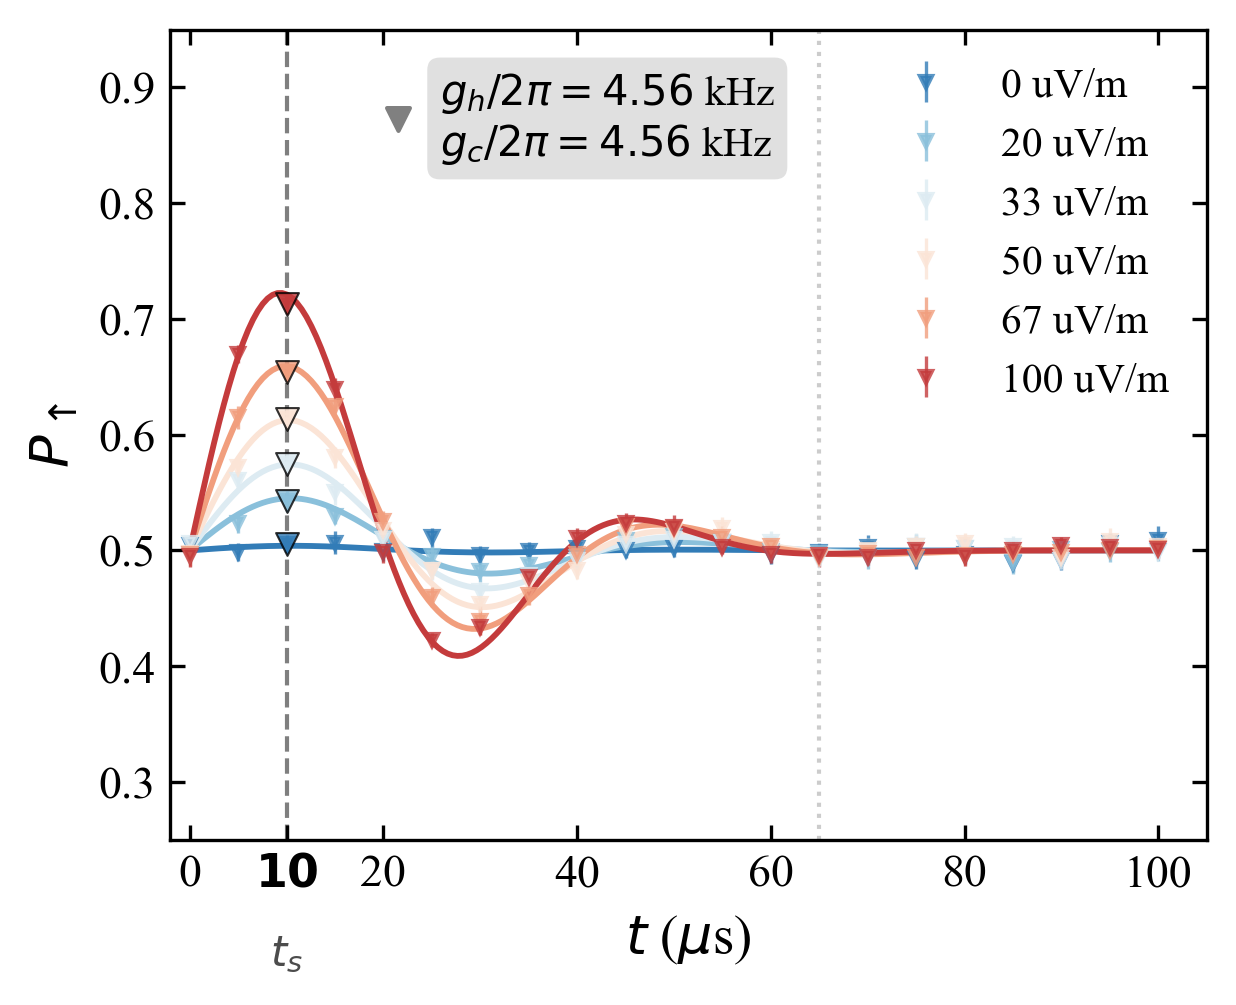

Figure saved as 'Fig3_Subplot_TimeEvolution_B4.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.

Label        | Fit E (uV/m)         | Steady <n>   | P_up @ 10us (Exp)    | Diff
--------------------------------------------------------------------------------------------------------------
0 uV/m       |    1.77 ± 0.01   | 3.56         | 0.5059               | +0.0000
20 uV/m      |   19.99 ± 0.06   | 3.61         | 0.5427               | +0.0000
33 uV/m      |   33.00 ± 0.29   | 3.69         | 0.5750               | +0.0000
50 uV/m      |   50.00 ± 0.97   | 3.87         | 0.6139               | +0.0000
67 uV/m      |   70.86 ± 2.38   | 4.21         | 0.6538               | +0.0000
100 uV/m     |   99.82 ± 2.35   | 4.96         | 0.7130               | +0.0000


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.optimize import curve_fit
import os
from datetime import datetime
from google.colab import files

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP simulation and curve fitting
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# Note: Adjust the zip filename if your B4 data is packed differently
!unzip -o -q Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B4.zip -d ./Fig3_data_B4/

# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Global Style Settings ==================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.0,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 300
})

# ================== 3. Physics Parameters (B4 Dataset) ==================
N = 60
eta = 0.114
# IMPORTANT: Omega_r and Omega_b are both 40 kHz for the B4 dataset
Omega_r, Omega_b = 2*np.pi*40e3, 2*np.pi*40e3
gammar, gammab = 150e3, 15e3
Omega_eff = 2*np.pi*50e3
phi_drive = 0
dphi = 2*np.pi

hbar, q = 1.054571817e-34, 1.602176634e-19
m = 40*1.66053906660e-27
omega_trap = 2*np.pi*676.35e3
x0 = np.sqrt(hbar/(2*m*omega_trap))

t_evol = 5.7e-3
nbar_init = 0.3
t0_us = 10
T_MAX_FIT = 65.0  # Strict physical truncation: only fit data points with t < 65 us

# ================== 4. Operators and Hamiltonian ==================
a = destroy(N)
I_m, I_i = qeye(N), qeye(3)
g, er, eb = basis(3,0), basis(3,1), basis(3,2)

sig_rg_tot = tensor(er*g.dag(), I_m)
sig_gr_tot = tensor(g*er.dag(), I_m)
sig_bg_tot = tensor(eb*g.dag(), I_m)
sig_gb_tot = tensor(g*eb.dag(), I_m)
a_tot, adag_tot = tensor(I_i, a), tensor(I_i, a.dag())

H0 = (0.5*1j*Omega_r*eta*(sig_gr_tot*adag_tot - sig_rg_tot*a_tot) +
      0.5*1j*Omega_b*eta*(sig_bg_tot*adag_tot - sig_gb_tot*a_tot))

c_ops = [np.sqrt(gammar)*sig_gr_tot, np.sqrt(gammab)*sig_gb_tot]
rho0 = tensor(g*g.dag(), thermal_dm(N, nbar_init))

# ================== 5. Fitting Model Functions ==================
rho_cache = {}

def get_rho_m(E_uV):
    key = round(float(E_uV), 8)
    if key in rho_cache: return rho_cache[key]
    E = E_uV * 1e-6
    H_drive = tensor(I_i, -(E*q*x0/(2j*hbar)) * (a*np.exp(1j*phi_drive) - a.dag()*np.exp(-1j*phi_drive)))
    sol = mesolve(H0 + H_drive, rho0, [0, t_evol], c_ops=c_ops, e_ops=[], options={'nsteps': 20000, 'max_step': 1e-5, 'atol': 1e-9, 'rtol': 1e-8, 'method': 'bdf'})
    rho_m = ptrace(sol.states[-1], 1)
    rho_cache[key] = rho_m
    return rho_m

def P_up_theory_scaled(tlist, E_uV):
    rho_m = get_rho_m(E_uV)
    P_list = []
    for t in tlist:
        beta = -1j * eta * Omega_eff * t * np.exp(-1j*dphi/2)
        D = displace(N, beta)
        chi = (D * rho_m).tr()
        P_list.append((1 - np.imag(chi)) / 2)
    return np.array(P_list)

# ================== 6. Data Compute or Load ==================
npz_filename = 'time_evolution_data_B4.npz'

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP simulation and fitting...")

    base_path = "./Fig3_data_B4"
    data_sets = {
        "0 uV/m":   f"{base_path}/B4/exp",
        "20 uV/m":  f"{base_path}/B4_20uV0phi/exp",
        "33 uV/m":  f"{base_path}/B4_33uV0phi/exp",
        "50 uV/m":  f"{base_path}/B4_50uV0phi/exp",
        "67 uV/m":  f"{base_path}/B4_67uV0phi/exp",
        "100 uV/m": f"{base_path}/B4_100uV0phi/exp",
    }

    results = {}
    save_data = {
        'labels': sorted(data_sets.keys(), key=lambda x: float(x.split()[0])),
        't_us_all': {}, 'P_mean_all': {}, 'P_sem_all': {},
        'fit_results': {}, 'fit_curves': {},
        'params': {'T_MAX_FIT': T_MAX_FIT, 't0_us': t0_us, 'eta': eta}
    }

    labels_sorted = save_data['labels']

    for i, label in enumerate(labels_sorted):
        print(f"Processing {label}...")
        folder = data_sets[label]
        rho_cache.clear()

        if not os.path.exists(folder):
            print(f"Folder not found: {folder}")
            continue

        files = [f for f in os.listdir(folder) if f.endswith(".txt")]
        files_sorted = sorted(files, key=lambda x: float(x.replace(".txt","")))
        t_us_list = np.array([float(f.replace(".txt","")) for f in files_sorted])
        t_exp = t_us_list * 1e-6

        P_mean_list, P_sem_list = [], []
        for f in files_sorted:
            data = np.loadtxt(os.path.join(folder, f))
            P_mean_list.append(np.mean(data))
            P_sem_list.append(np.std(data, ddof=1)/np.sqrt(len(data)))
        P_mean = np.array(P_mean_list)
        P_sem = np.array(P_sem_list)

        save_data['t_us_all'][label] = t_us_list
        save_data['P_mean_all'][label] = P_mean
        save_data['P_sem_all'][label] = P_sem

        fit_mask = t_us_list < T_MAX_FIT
        t_exp_fit = t_exp[fit_mask]
        P_mean_fit = P_mean[fit_mask]
        fit_weights = P_sem[fit_mask].copy()

        nominal_E = float(label.split()[0])
        try:
            popt, pcov = curve_fit(P_up_theory_scaled, t_exp_fit, P_mean_fit, sigma=fit_weights, absolute_sigma=True, p0=[nominal_E], bounds=(-5, 200), ftol=1e-10, xtol=1e-10)
            E_fit, E_err = popt[0], np.sqrt(pcov[0,0])
        except Exception as e:
            print(f"Fit failed for {label}: {e}")
            E_fit, E_err = nominal_E, 0.0

        rho_f = get_rho_m(E_fit)
        n_steady = expect(a.dag()*a, rho_f).real
        results[label] = {"E_fit": E_fit, "E_err": E_err, "nbar": n_steady}
        save_data['fit_results'][label] = results[label]

        t_dense = np.linspace(0, 100e-6, 200)
        P_dense = P_up_theory_scaled(t_dense, E_fit)
        save_data['fit_curves'][label] = {'t_us': t_dense * 1e6, 'P': P_dense}

    np.savez(npz_filename, **save_data)
    print(f"Data saved to {npz_filename}")

else:
    print(f"Loading pre-computed data from GitHub repository...")
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/{npz_filename}'

    if os.path.exists(npz_path):
        data = np.load(npz_path, allow_pickle=True)
        labels = data['labels'].tolist()
        t_us_all = data['t_us_all'].item()
        P_mean_all = data['P_mean_all'].item()
        P_sem_all = data['P_sem_all'].item()
        fit_curves = data['fit_curves'].item()
        results_dict = data['fit_results'].item()
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 7. Plotting (B4 Style: Downward Triangle Markers) ==================
print("Generating Figure...")
fig, ax = plt.subplots(figsize=(4.0, 3.2))

# Color palette matching Fig. 1 (RdBu_r)
n_colors = len(labels)
cmap = plt.get_cmap('RdBu_r')
positions = np.linspace(0.15, 0.85, n_colors)
vline_colors = [cmap(pos) for pos in positions]

for i, label in enumerate(labels):
    color = vline_colors[i]
    t_us = t_us_all[label]
    P_mean = P_mean_all[label]
    P_sem = P_sem_all[label]

    # Use downward triangle markers ('v') for B4 dataset
    ax.errorbar(t_us, P_mean, yerr=P_sem, fmt='v', color=color, markersize=3.0, elinewidth=0.8, capsize=0, alpha=0.8, label=label)

    # Highlight the data point at t=10 us with black edge
    idx_10 = np.where(np.isclose(t_us, 10, atol=0.5))[0]
    if len(idx_10) > 0:
        ax.scatter(t_us[idx_10], P_mean[idx_10], color=color, s=30, marker='v', edgecolor='k', linewidth=0.5, facecolor=color, zorder=5, alpha=0.8)

    curve = fit_curves[label]
    ax.plot(curve['t_us'], curve['P'], '-', color=color, lw=1.4)

# Vertical markers
ax.axvline(x=10, color='black', linestyle='--', linewidth=1.0, alpha=0.5, zorder=0)
y_pos = ax.get_ylim()[0] - 0.26
ax.text(10, y_pos, '$t_s$', ha='center', va='bottom', fontsize=10, color='black', alpha=0.7)
ax.axvline(x=65, color='gray', linestyle=':', linewidth=1.0, alpha=0.4, zorder=0)

# Parameter annotation box (B4 specific parameters)
ax.scatter(0.22, 0.89, s=30, color='gray', marker='v', transform=ax.transAxes, clip_on=False)
param_text = r"$g_h/2\pi = 4.56$ kHz" + "\n" + r"$g_c/2\pi = 4.56$ kHz"
ax.text(0.26, 0.95, param_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', fontfamily='serif', linespacing=1.2, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', edgecolor='none', alpha=0.7))

# Axis labels and ranges
ax.set_xlabel(r"$t$ ($\mu$s)")
ax.set_ylabel(r"$P_{\uparrow}$")
ax.set_xticks([0, 10, 20, 40, 60, 80, 100])
ax.set_xticklabels(['0', r'$\mathbf{10}$', '20', '40', '60', '80', '100'], fontsize=11)
ax.set_xlim(-2, 105)
ax.set_ylim(0.25, 0.95)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout(pad=0.2)

# ================== 8. Save and Download ==================
pdf_name = 'Fig3_Subplot_TimeEvolution_B4.pdf'
plt.savefig(pdf_name, dpi=600, bbox_inches='tight')
plt.show()
print(f"Figure saved as '{pdf_name}'")

try:
    files.download(pdf_name)
    print("PDF download triggered.")
except Exception as e:
    print("Automatic download failed. Download manually from file browser.")

# ================== 9. Terminal Table Output ==================
print("\n" + "="*110)
print(f"{'Label':<12} | {'Fit E (uV/m)':<20} | {'Steady <n>':<12} | {'P_up @ 10us (Exp)':<20} | {'Diff'}")
print("-"*110)

if RECOMPUTE_DATA:
    res_dict = save_data['fit_results']
else:
    res_dict = results_dict

for label in labels:
    if label in res_dict:
        res = res_dict[label]
        exp_data = P_mean_all[label]
        t_10 = np.where(np.isclose(t_us_all[label], 10, atol=0.5))[0]
        p10_exp = exp_data[t_10[0]] if len(t_10) > 0 else 0

        diff = 0.0
        if RECOMPUTE_DATA:
            diff = p10_exp - P_up_theory_scaled([t0_us*1e-6], res['E_fit'])[0]

        print(f"{label:<12} | {res['E_fit']:>7.2f} ± {res['E_err']:<6.2f} | {res['nbar']:<12.2f} | {p10_exp:<20.4f} | {diff:>+7.4f}")
print("="*110)

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 107 (delta 39), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 2.42 MiB | 15.98 MiB/s, done.
Resolving deltas: 100% (39/39), done.
unzip:  cannot find or open Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B64.zip, Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B64.zip.zip or Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B64.zip.ZIP.
Loading pre-computed data from GitHub repository...
Generating Figure...


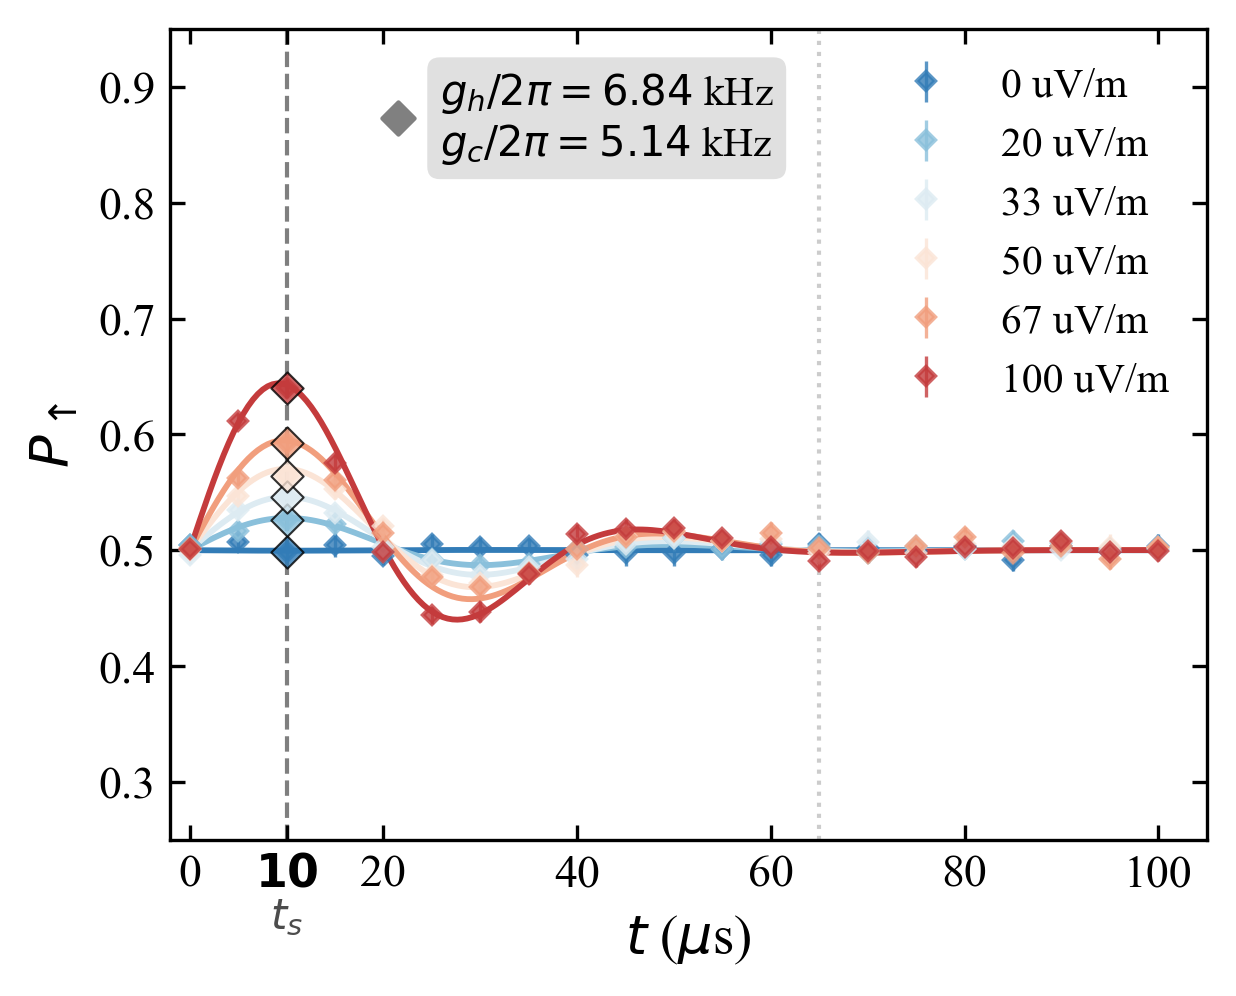

Figure saved as 'Fig3_Subplot_TimeEvolution_B64.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.

Label        | Fit E (uV/m)         | Steady <n>   | P_up @ 10us (Exp)    | Diff
--------------------------------------------------------------------------------------------------------------
0 uV/m       |   -0.32 ± 1.16   | 3.56         | 0.4986               | +0.0000
20 uV/m      |   19.98 ± 0.04   | 3.59         | 0.5262               | +0.0000
33 uV/m      |   33.00 ± 0.09   | 3.65         | 0.5460               | +0.0000
50 uV/m      |   50.00 ± 0.64   | 3.78         | 0.5639               | +0.0000
67 uV/m      |   67.00 ± 1.14   | 3.97         | 0.5927               | +0.0000
100 uV/m     |   99.69 ± 1.21   | 4.59         | 0.6405               | +0.0000


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.optimize import curve_fit
import os
from datetime import datetime
from google.colab import files

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP simulation and curve fitting
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# Note: Adjust the zip filename if your B64 data is packed differently
!unzip -o -q Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/Fig3_data_B64.zip -d ./Fig3_data_B64/

# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Global Style Settings ==================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "lines.linewidth": 1.0,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 300
})

# ================== 3. Physics Parameters (B64 Dataset) ==================
N = 60
eta = 0.114
# IMPORTANT: Omega_b is 60 kHz for the B64 dataset (others are 20 kHz)
Omega_r, Omega_b = 2*np.pi*45.1e3, 2*np.pi*60e3
gammar, gammab = 150e3, 15e3
Omega_eff = 2*np.pi*50e3
phi_drive = 0
dphi = 2*np.pi

hbar, q = 1.054571817e-34, 1.602176634e-19
m = 40*1.66053906660e-27
omega_trap = 2*np.pi*676.35e3
x0 = np.sqrt(hbar/(2*m*omega_trap))

t_evol = 5.7e-3
nbar_init = 0.3
t0_us = 10
T_MAX_FIT = 65.0  # Strict physical truncation: only fit data points with t < 65 us

# ================== 4. Operators and Hamiltonian ==================
a = destroy(N)
I_m, I_i = qeye(N), qeye(3)
g, er, eb = basis(3,0), basis(3,1), basis(3,2)

sig_rg_tot = tensor(er*g.dag(), I_m)
sig_gr_tot = tensor(g*er.dag(), I_m)
sig_bg_tot = tensor(eb*g.dag(), I_m)
sig_gb_tot = tensor(g*eb.dag(), I_m)
a_tot, adag_tot = tensor(I_i, a), tensor(I_i, a.dag())

H0 = (0.5*1j*Omega_r*eta*(sig_gr_tot*adag_tot - sig_rg_tot*a_tot) +
      0.5*1j*Omega_b*eta*(sig_bg_tot*adag_tot - sig_gb_tot*a_tot))

c_ops = [np.sqrt(gammar)*sig_gr_tot, np.sqrt(gammab)*sig_gb_tot]
rho0 = tensor(g*g.dag(), thermal_dm(N, nbar_init))

# ================== 5. Fitting Model Functions ==================
rho_cache = {}

def get_rho_m(E_uV):
    key = round(float(E_uV), 8)
    if key in rho_cache: return rho_cache[key]
    E = E_uV * 1e-6
    H_drive = tensor(I_i, -(E*q*x0/(2j*hbar)) * (a*np.exp(1j*phi_drive) - a.dag()*np.exp(-1j*phi_drive)))
    sol = mesolve(H0 + H_drive, rho0, [0, t_evol], c_ops=c_ops, e_ops=[], options={'nsteps': 20000, 'max_step': 1e-5, 'atol': 1e-9, 'rtol': 1e-8, 'method': 'bdf'})
    rho_m = ptrace(sol.states[-1], 1)
    rho_cache[key] = rho_m
    return rho_m

def P_up_theory_scaled(tlist, E_uV):
    rho_m = get_rho_m(E_uV)
    P_list = []
    for t in tlist:
        beta = -1j * eta * Omega_eff * t * np.exp(-1j*dphi/2)
        D = displace(N, beta)
        chi = (D * rho_m).tr()
        P_list.append((1 - np.imag(chi)) / 2)
    return np.array(P_list)

# ================== 6. Data Compute or Load ==================
npz_filename = 'time_evolution_data_B64.npz'

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP simulation and fitting...")

    base_path = "./Fig3_data_B64"
    data_sets = {
        "0 uV/m":   f"{base_path}/B64/exp",
        "20 uV/m":  f"{base_path}/B64_20uV0phi/exp",
        "33 uV/m":  f"{base_path}/B64_33uV0phi/exp",
        "50 uV/m":  f"{base_path}/B64_50uV0phi/exp",
        "67 uV/m":  f"{base_path}/B64_67uV0phi/exp",
        "100 uV/m": f"{base_path}/B64_100uV0phi/exp",
    }

    results = {}
    save_data = {
        'labels': sorted(data_sets.keys(), key=lambda x: float(x.split()[0])),
        't_us_all': {}, 'P_mean_all': {}, 'P_sem_all': {},
        'fit_results': {}, 'fit_curves': {},
        'params': {'T_MAX_FIT': T_MAX_FIT, 't0_us': t0_us, 'eta': eta}
    }

    labels_sorted = save_data['labels']

    for i, label in enumerate(labels_sorted):
        print(f"Processing {label}...")
        folder = data_sets[label]
        rho_cache.clear()

        if not os.path.exists(folder):
            print(f"Folder not found: {folder}")
            continue

        files = [f for f in os.listdir(folder) if f.endswith(".txt")]
        files_sorted = sorted(files, key=lambda x: float(x.replace(".txt","")))
        t_us_list = np.array([float(f.replace(".txt","")) for f in files_sorted])
        t_exp = t_us_list * 1e-6

        P_mean_list, P_sem_list = [], []
        for f in files_sorted:
            data = np.loadtxt(os.path.join(folder, f))
            P_mean_list.append(np.mean(data))
            P_sem_list.append(np.std(data, ddof=1)/np.sqrt(len(data)))
        P_mean = np.array(P_mean_list)
        P_sem = np.array(P_sem_list)

        save_data['t_us_all'][label] = t_us_list
        save_data['P_mean_all'][label] = P_mean
        save_data['P_sem_all'][label] = P_sem

        fit_mask = t_us_list < T_MAX_FIT
        t_exp_fit = t_exp[fit_mask]
        P_mean_fit = P_mean[fit_mask]
        fit_weights = P_sem[fit_mask].copy()

        nominal_E = float(label.split()[0])
        try:
            popt, pcov = curve_fit(P_up_theory_scaled, t_exp_fit, P_mean_fit, sigma=fit_weights, absolute_sigma=True, p0=[nominal_E], bounds=(-5, 200), ftol=1e-10, xtol=1e-10)
            E_fit, E_err = popt[0], np.sqrt(pcov[0,0])
        except Exception as e:
            print(f"Fit failed for {label}: {e}")
            E_fit, E_err = nominal_E, 0.0

        rho_f = get_rho_m(E_fit)
        n_steady = expect(a.dag()*a, rho_f).real
        results[label] = {"E_fit": E_fit, "E_err": E_err, "nbar": n_steady}
        save_data['fit_results'][label] = results[label]

        t_dense = np.linspace(0, 100e-6, 200)
        P_dense = P_up_theory_scaled(t_dense, E_fit)
        save_data['fit_curves'][label] = {'t_us': t_dense * 1e6, 'P': P_dense}

    np.savez(npz_filename, **save_data)
    print(f"Data saved to {npz_filename}")

else:
    print(f"Loading pre-computed data from GitHub repository...")
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/{npz_filename}'

    if os.path.exists(npz_path):
        data = np.load(npz_path, allow_pickle=True)
        labels = data['labels'].tolist()
        t_us_all = data['t_us_all'].item()
        P_mean_all = data['P_mean_all'].item()
        P_sem_all = data['P_sem_all'].item()
        fit_curves = data['fit_curves'].item()
        results_dict = data['fit_results'].item()
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 7. Plotting (B64 Style: Diamond Markers) ==================
print("Generating Figure...")
fig, ax = plt.subplots(figsize=(4.0, 3.2))

# Color palette matching Fig. 1 (RdBu_r)
n_colors = len(labels)
cmap = plt.get_cmap('RdBu_r')
positions = np.linspace(0.15, 0.85, n_colors)
vline_colors = [cmap(pos) for pos in positions]

for i, label in enumerate(labels):
    color = vline_colors[i]
    t_us = t_us_all[label]
    P_mean = P_mean_all[label]
    P_sem = P_sem_all[label]

    # Use diamond markers ('D') for B64 dataset
    ax.errorbar(t_us, P_mean, yerr=P_sem, fmt='D', color=color, markersize=3.0, elinewidth=0.8, capsize=0, alpha=0.8, label=label)

    # Highlight the data point at t=10 us with black edge
    idx_10 = np.where(np.isclose(t_us, 10, atol=0.5))[0]
    if len(idx_10) > 0:
        ax.scatter(t_us[idx_10], P_mean[idx_10], color=color, s=30, marker='D', edgecolor='k', linewidth=0.5, facecolor=color, zorder=5, alpha=0.8)

    curve = fit_curves[label]
    ax.plot(curve['t_us'], curve['P'], '-', color=color, lw=1.4)

# Vertical markers
ax.axvline(x=10, color='black', linestyle='--', linewidth=1.0, alpha=0.5, zorder=0)
y_pos = ax.get_ylim()[0] - 0.26
ax.text(10, y_pos, '$t_s$', ha='center', va='bottom', fontsize=10, color='black', alpha=0.7)
ax.axvline(x=65, color='gray', linestyle=':', linewidth=1.0, alpha=0.4, zorder=0)

# Parameter annotation box (B64 specific parameters)
ax.scatter(0.22, 0.89, s=30, color='gray', marker='D', transform=ax.transAxes, clip_on=False)
param_text = r"$g_h/2\pi = 6.84$ kHz" + "\n" + r"$g_c/2\pi = 5.14$ kHz"
ax.text(0.26, 0.95, param_text, transform=ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', fontfamily='serif', linespacing=1.2, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', edgecolor='none', alpha=0.7))

# Axis labels and ranges
ax.set_xlabel(r"$t$ ($\mu$s)")
ax.set_ylabel(r"$P_{\uparrow}$")
ax.set_xticks([0, 10, 20, 40, 60, 80, 100])
ax.set_xticklabels(['0', r'$\mathbf{10}$', '20', '40', '60', '80', '100'], fontsize=11)
ax.set_xlim(-2, 105)
ax.set_ylim(0.25, 0.95)
ax.legend(loc='upper right', frameon=False)

plt.tight_layout(pad=0.2)

# ================== 8. Save and Download ==================
pdf_name = 'Fig3_Subplot_TimeEvolution_B64.pdf'
plt.savefig(pdf_name, dpi=600, bbox_inches='tight')
plt.show()
print(f"Figure saved as '{pdf_name}'")

try:
    files.download(pdf_name)
    print("PDF download triggered.")
except Exception as e:
    print("Automatic download failed. Download manually from file browser.")

# ================== 9. Terminal Table Output ==================
print("\n" + "="*110)
print(f"{'Label':<12} | {'Fit E (uV/m)':<20} | {'Steady <n>':<12} | {'P_up @ 10us (Exp)':<20} | {'Diff'}")
print("-"*110)

if RECOMPUTE_DATA:
    res_dict = save_data['fit_results']
else:
    res_dict = results_dict

for label in labels:
    if label in res_dict:
        res = res_dict[label]
        exp_data = P_mean_all[label]
        t_10 = np.where(np.isclose(t_us_all[label], 10, atol=0.5))[0]
        p10_exp = exp_data[t_10[0]] if len(t_10) > 0 else 0

        diff = 0.0
        if RECOMPUTE_DATA:
            diff = p10_exp - P_up_theory_scaled([t0_us*1e-6], res['E_fit'])[0]

        print(f"{label:<12} | {res['E_fit']:>7.2f} ± {res['E_err']:<6.2f} | {res['nbar']:<12.2f} | {p10_exp:<20.4f} | {diff:>+7.4f}")
print("="*110)

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 112 (delta 42), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 2.42 MiB | 16.11 MiB/s, done.
Resolving deltas: 100% (42/42), done.
Loading pre-computed data from GitHub repository...
Generating Figure...


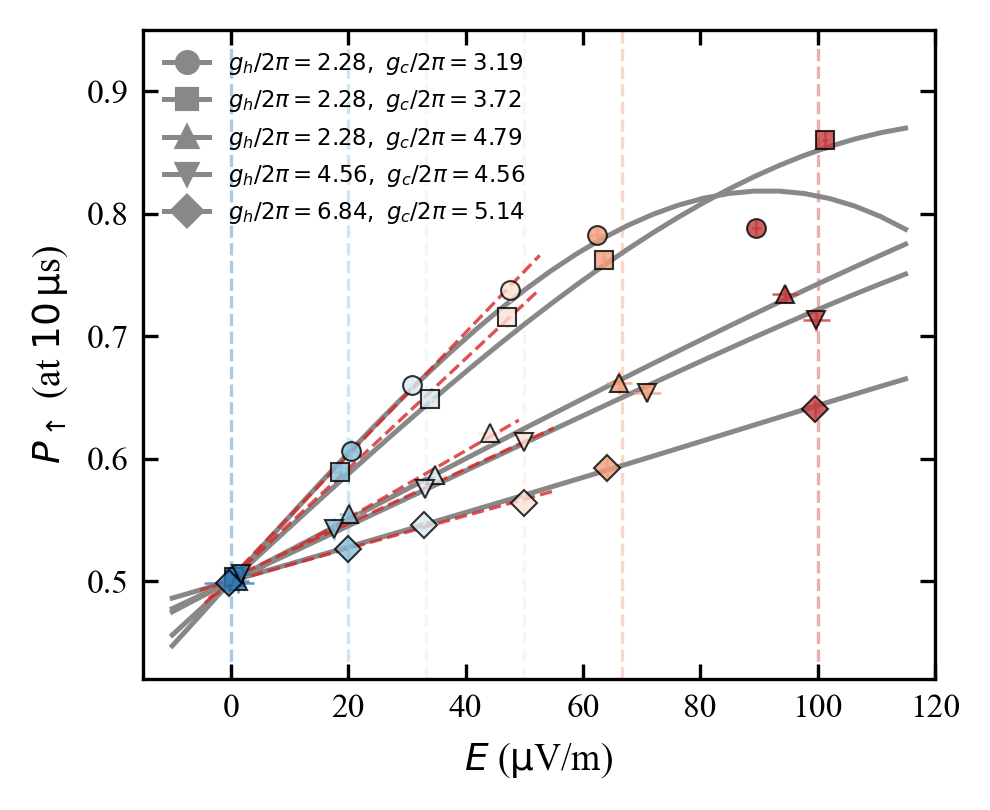

Figure saved as 'Fig3_Sensitivity_UnifiedStyle_20260914.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.

Label              | Slope (1/uV)       | Theory dE (uV/m/sqrtHz) | Exp dE/sqrtHz (uV/m/sqrtHz)
-----------------------------------------------------------------------------------------------------------------------------
28 / 20 kHz        | 4.9965e-03±2.7e-04 | 13.33                  | 14.15 ± 0.77             
32.6 / 20 kHz      | 4.4915e-03±2.2e-04 | 16.05                  | 15.74 ± 0.78             
42 / 20 kHz        | 2.7499e-03±3.0e-04 | 28.18                  | 25.71 ± 2.77             
45.1 / 60 kHz      | 1.3392e-03±2.2e-04 | 50.83                  | 52.80 ± 8.65             
40 / 40 kHz        | 2.2286e-03±2.2e-04 | 31.41                  | 31.73 ± 3.15             



In [19]:
import warnings
import logging
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.optimize import curve_fit
import os
from datetime import datetime
from google.colab import files

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP simulation and curve fitting
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Global Physics Parameters ==================
N = 60
eta = 0.114
Omega_eff = 2*np.pi*50e3
phi_drive = 0
dphi = 2*np.pi

hbar, q = 1.054571817e-34, 1.602176634e-19
m = 40 * 1.66053906660e-27
omega_trap = 2*np.pi*676.35e3
x0 = np.sqrt(hbar / (2 * m * omega_trap))

t_evol = 5.7e-3
t0 = 10e-6
T_cycle = 0.02

opts = {'nsteps': 20000, 'max_step': 1e-5, 'atol': 1e-9, 'rtol': 1e-8, 'method': 'bdf'}

# ================== 3. Parameter Sets & Experimental Data ==================
param_sets = [
    {"label": "28 / 20 kHz", "Omega_r": 2*np.pi*28e3, "Omega_b": 2*np.pi*20e3, "gammar": 150e3, "gammab": 15e3, "color": "#2E86AB"},
    {"label": "32.6 / 20 kHz", "Omega_r": 2*np.pi*32.6e3, "Omega_b": 2*np.pi*20e3, "gammar": 150e3, "gammab": 15e3, "color": "#F18F01"},
    {"label": "42 / 20 kHz", "Omega_r": 2*np.pi*42e3, "Omega_b": 2*np.pi*20e3, "gammar": 150e3, "gammab": 15e3, "color": "#A23B72"},
    {"label": "45.1 / 60 kHz", "Omega_r": 2*np.pi*45.1e3, "Omega_b": 2*np.pi*60e3, "gammar": 150e3, "gammab": 15e3, "color": "#4A90E2"},
    {"label": "40 / 40 kHz", "Omega_r": 2*np.pi*40e3, "Omega_b": 2*np.pi*40e3, "gammar": 150e3, "gammab": 15e3, "color": "#2ECC71"}
]

exp_data = {
    "28 / 20 kHz": {"E": np.array([0.55, 20.48, 30.80, 47.63, 62.47, 89.57]), "E_err": np.array([1.02, 1.13, 1.17, 1.31, 1.25, 0.76]), "P": np.array([0.5040, 0.6064, 0.6603, 0.7379, 0.7829, 0.7885]), "P_err": np.array([0.0089, 0.0094, 0.0088, 0.0097, 0.0058, 0.0062])},
    "32.6 / 20 kHz": {"E": np.array([0.57, 18.66, 33.90, 47.04, 63.60, 101.24]), "E_err": np.array([0.87, 1.07, 1.21, 1.45, 0.60, 0.49]), "P": np.array([0.5034, 0.5887, 0.6487, 0.7158, 0.7625, 0.8600]), "P_err": np.array([0.0068, 0.0062, 0.0079, 0.0090, 0.0062, 0.0078])},
    "42 / 20 kHz": {"E": np.array([1.24, 20.20, 34.80, 44.08, 66.18, 94.44]), "E_err": np.array([1.91, 1.82, 1.75, 2.05, 2.26, 2.20]), "P": np.array([0.4997, 0.5549, 0.5863, 0.6212, 0.6621, 0.7343]), "P_err": np.array([0.0098, 0.0099, 0.0092, 0.0093, 0.0095, 0.0070])},
    "45.1 / 60 kHz": {"E": np.array([-0.31, 20.00, 32.99, 50.00, 64.03, 99.49]), "E_err": np.array([4.30, 0.04, 0.01, 1.89, 0.08, 0.12]), "P": np.array([0.4986, 0.5262, 0.5460, 0.5639, 0.5927, 0.6405]), "P_err": np.array([0.0074, 0.0084, 0.0062, 0.0094, 0.0081, 0.0075])},
    "40 / 40 kHz": {"E": np.array([1.77, 17.56, 33.00, 50.00, 70.86, 99.82]), "E_err": np.array([1.40, 0.07, 0.12, 0.98, 2.38, 2.35]), "P": np.array([0.5059, 0.5427, 0.575, 0.6139, 0.6538, 0.713]), "P_err": np.array([0.0075, 0.0091, 0.0086, 0.0082, 0.0077, 0.0091])}
}

def linear_func(E, a, b): return a * E + b

# ================== 4. Compute or Load Data ==================
npz_filename = 'sql_theory_data.npz'
results_summary = []

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP simulation and fitting...")

    E_plot_range_uV = np.linspace(-10, 115, 30)
    theory_data = {}

    a = destroy(N)
    I_m, I_i = qeye(N), qeye(3)
    g, er, eb = basis(3,0), basis(3,1), basis(3,2)
    sig_rg_tot = tensor(er*g.dag(), I_m)
    sig_gr_tot = tensor(g*er.dag(), I_m)
    sig_bg_tot = tensor(eb*g.dag(), I_m)
    sig_gb_tot = tensor(g*eb.dag(), I_m)
    a_tot, adag_tot = tensor(I_i, a), tensor(I_i, a.dag())
    rho0 = tensor(g*g.dag(), thermal_dm(N, 0.3))

    beta0 = -1j * eta * Omega_eff * t0 * np.exp(-1j * dphi / 2)
    D = displace(N, beta0)

    for idx, p in enumerate(param_sets):
        label = p["label"]
        print(f"Calculating full 10us realigned theory for {label}...")

        H0 = (0.5 * 1j * p["Omega_r"] * eta * (sig_gr_tot * adag_tot - sig_rg_tot * a_tot) +
              0.5 * 1j * p["Omega_b"] * eta * (sig_bg_tot * adag_tot - sig_gb_tot * a_tot))
        c_ops = [np.sqrt(p["gammar"]) * sig_gr_tot, np.sqrt(p["gammab"]) * sig_gb_tot]

        P_theory = []
        for E_uV in E_plot_range_uV:
            E_V = E_uV * 1e-6
            H_drive = tensor(I_i, -(E_V * q * x0 / (2j * hbar)) * (a * np.exp(1j * phi_drive) - a.dag() * np.exp(-1j * phi_drive)))
            sol = mesolve(H0 + H_drive, rho0, [0, t_evol], c_ops=c_ops, options=opts)
            rho_m = ptrace(sol.states[-1], 1)
            chi = (D * rho_m).tr()
            P_theory.append((1 - np.imag(chi)) / 2)

        P_theory = np.array(P_theory)
        theory_data[label] = P_theory

        idx0 = np.argmin(np.abs(P_theory - 0.5))
        theory_slope = np.gradient(P_theory, E_plot_range_uV)[idx0]
        theory_sens = (0.5 / abs(theory_slope)) * np.sqrt(T_cycle)

        if label in exp_data:
            d = exp_data[label]
            popt, pcov = curve_fit(linear_func, d["E"][:4], d["P"][:4], sigma=d["P_err"][:4], absolute_sigma=True)
            slope, intercept = popt
            slope_err = np.sqrt(pcov[0,0])
            deltaE_exp = (0.5 / abs(slope)) * np.sqrt(T_cycle)
            deltaE_err = deltaE_exp * (slope_err / abs(slope))
            results_summary.append([label, slope, slope_err, intercept, deltaE_exp, deltaE_err, theory_sens])

    np.savez(npz_filename, E_plot=E_plot_range_uV, theory_data=theory_data, exp_data=exp_data,
             param_sets=param_sets, markers=['o', 's', '^', 'v', 'D'],
             vline_colors=['#E74C3C', '#F39C12', '#2ECC71', '#3498DB', '#9B59B6', '#1ABC9C'],
             E_lines=[0, 20, 33.3, 50, 66.7, 100], results_summary=results_summary)
    print(f"Data saved to {npz_filename}")

else:
    print(f"Loading pre-computed data from GitHub repository...")
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/{npz_filename}'
    if not os.path.exists(npz_path):
        npz_path = npz_filename # Fallback to current directory

    if os.path.exists(npz_path):
        data = np.load(npz_path, allow_pickle=True)
        E_plot_range_uV = data['E_plot']
        theory_data = data['theory_data'].item()
        exp_data = data['exp_data'].item()
        param_sets = data['param_sets'].tolist()
        markers = data['markers']
        vline_colors = data['vline_colors']
        E_theoretical_lines = data['E_lines']

        # Recompute results_summary from exp_data (fast, no QuTiP needed)
        results_summary = []
        for idx, p in enumerate(param_sets):
            label = p["label"]
            if label in exp_data:
                d = exp_data[label]
                popt, pcov = curve_fit(linear_func, d["E"][:4], d["P"][:4], sigma=d["P_err"][:4], absolute_sigma=True)
                slope, intercept = popt
                slope_err = np.sqrt(pcov[0,0])
                deltaE_exp = (0.5 / abs(slope)) * np.sqrt(T_cycle)
                deltaE_err = deltaE_exp * (slope_err / abs(slope))

                P_theory = theory_data[label]
                idx0 = np.argmin(np.abs(P_theory - 0.5))
                theory_slope = np.gradient(P_theory, E_plot_range_uV)[idx0]
                theory_sens = (0.5 / abs(theory_slope)) * np.sqrt(T_cycle)

                results_summary.append([label, slope, slope_err, intercept, deltaE_exp, deltaE_err, theory_sens])
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 5. Plotting (Merged Style from User's Second Script) ==================
print("Generating Figure...")

# Rebuild vline_colors using the exact RdBu_r mapping from the user's plotting script
cmap = plt.get_cmap('RdBu_r')
n_colors = 6
positions = np.linspace(0.15, 0.85, n_colors)
vline_colors = [cmap(pos) for pos in positions]
E_lines = [0, 20, 33.3, 50, 66.7, 100]

CURVE_COLOR = '#888888'
FIT_COLOR   = '#D62728'

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

fig, ax = plt.subplots(figsize=(3.4, 2.8))
ax.grid(False)

# Draw vertical lines
for e_val, color in zip(E_lines, vline_colors):
    ax.axvline(x=e_val, color=color, linestyle='--', linewidth=0.8, alpha=0.4, zorder=1)

handles = []
labels = []

legend_texts = [
    r"$g_h/2\pi = 2.28,\ g_c/2\pi = 3.19$",
    r"$g_h/2\pi = 2.28,\ g_c/2\pi = 3.72$",
    r"$g_h/2\pi = 2.28,\ g_c/2\pi = 4.79$",
    r"$g_h/2\pi = 6.84,\ g_c/2\pi = 5.14$",
    r"$g_h/2\pi = 4.56,\ g_c/2\pi = 4.56$"
]

# Mapping function for experimental point colors
def get_color_for_E(E_val):
    idx = np.argmin(np.abs(np.array(E_lines) - E_val))
    return vline_colors[idx]

for idx, p in enumerate(param_sets):
    label = p['label']
    legend_text = legend_texts[idx]

    # Marker assignment
    if idx == 3:
        marker = 'D'
    elif idx == 4:
        marker = 'v'
    else:
        marker = markers[idx]

    # Theoretical curve (Unified gray)
    P_theory = theory_data[label]
    ax.plot(E_plot_range_uV, P_theory, ls='-', color=CURVE_COLOR, lw=1.2)

    # Experimental data
    if label in exp_data:
        d = exp_data[label]
        for E_val, P_val, E_err, P_err in zip(d['E'], d['P'], d['E_err'], d['P_err']):
            color_point = get_color_for_E(E_val)
            ax.errorbar(E_val, P_val, xerr=E_err, yerr=P_err, fmt=marker,
                        color=color_point, mec='k', mew=0.5, mfc=color_point,
                        ms=4.5, elinewidth=0.6, capsize=0, alpha=0.8)

        # Fit line (Unified red)
        E_fit = d['E'][:4]
        P_fit = d['P'][:4]
        P_err_fit = d['P_err'][:4]
        try:
            popt, _ = curve_fit(linear_func, E_fit, P_fit, sigma=P_err_fit, absolute_sigma=True)
            x_fit = np.linspace(min(E_fit)-5, max(E_fit)+5, 10)
            ax.plot(x_fit, linear_func(x_fit, *popt), '--', color=FIT_COLOR, lw=0.8, alpha=0.8)
        except Exception as e:
            print(f"Fit failed for {label}: {e}")

    # Legend handles
    h = ax.plot([], [], color=CURVE_COLOR, marker=marker, linestyle='-', lw=1.2, markersize=5)[0]
    handles.append(h)
    labels.append(legend_text)

# Swap legend order for indices 3 and 4 (Diamond and Down-Triangle)
handles[3], handles[4] = handles[4], handles[3]
labels[3], labels[4] = labels[4], labels[3]

ax.legend(handles, labels, loc='upper left', frameon=False, fontsize=5.5)
ax.tick_params(top=True, right=True, which='both', labelsize=8)
ax.set_xlabel(r"$E$ ($\mathrm{\mu}$V/m)", fontsize=9)
ax.set_ylabel(r"$P_{\uparrow}$ (at $10\,\mathrm{\mu}$s)", fontsize=9)
ax.set_xlim(-15, 120)
ax.set_ylim(0.42, 0.95)

plt.tight_layout()

# ================== 6. Save and Download ==================
run_date = datetime.now().strftime("%Y%m%d")
pdf_filename = f"Fig3_Sensitivity_UnifiedStyle_{run_date}.pdf"
plt.savefig(pdf_filename, dpi=600, bbox_inches='tight')
plt.show()
print(f"Figure saved as '{pdf_filename}'")

try:
    files.download(pdf_filename)
    print("PDF download triggered.")
except Exception as e:
    print("Automatic download failed. Download manually from file browser.")

# ================== 7. Summary Table Output ==================
print("\n" + "="*125)
print(f"{'Label':<18} | {'Slope (1/uV)':<18} | {'Theory dE (uV/m/sqrtHz)':<22} | {'Exp dE/sqrtHz (uV/m/sqrtHz)':<25}")
print("-" * 125)
for r in results_summary:
    slope_str = f"{r[1]:.4e}±{r[2]:.1e}"
    exp_sens_str = f"{r[4]:.2f} ± {r[5]:.2f}"
    print(f"{r[0]:<18} | {slope_str:<18} | {r[6]:<22.2f} | {exp_sens_str:<25}")
print("="*125 + "\n")

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 127 (delta 49), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 2.55 MiB | 16.13 MiB/s, done.
Resolving deltas: 100% (49/49), done.
Loading pre-computed data from GitHub repository...
Data loaded successfully.
Generating Figure...


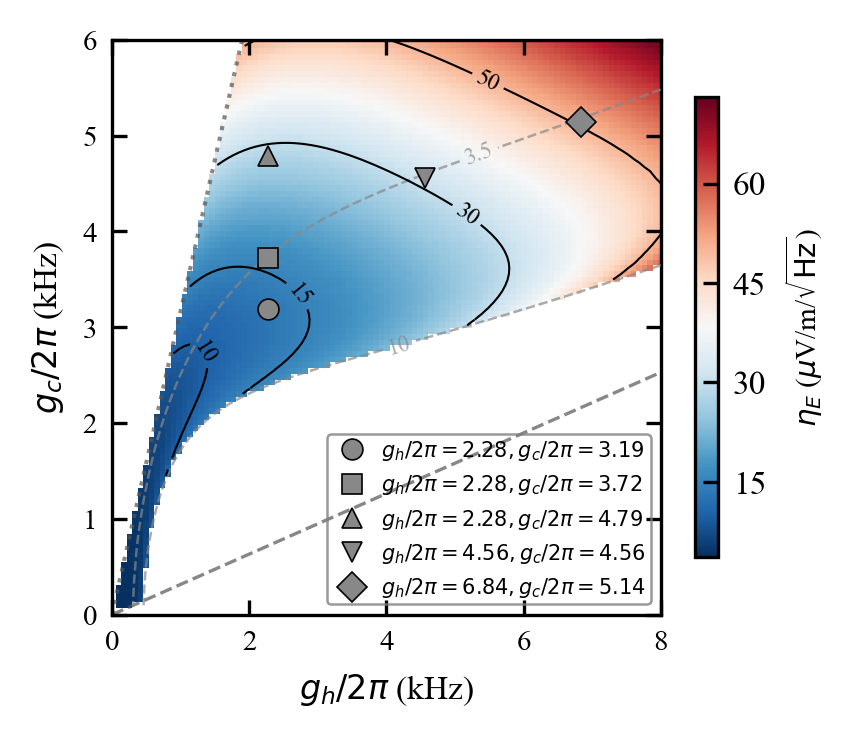

Figure saved as 'Fig3_SensitivityMap_Subplot_20260914.pdf'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PDF download triggered.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from qutip import *
import os
import sys
import warnings
import logging
from datetime import datetime
import pandas as pd
from google.colab import files

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file from GitHub
# and instantly reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP simulation from scratch
# (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Colab Environment Preparation ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Global Style Settings ==================
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 300
})

# ================== 3. Physical & Simulation Parameters ==================
RESOLUTION = 100
N_cutoff = 25
eta = 0.114
gammah_val, gammac_val = 15e3, 150e3
Omega_eff = 2 * np.pi * 50e3
t_evol = 5.7e-3
t0 = 10e-6
T_cycle = 0.02
dphi = 2 * np.pi
hbar = 1.054571817e-34
q = 1.602176634e-19
m = 40 * 1.66053906660e-27
omega_trap = 2 * np.pi * 676.35e3
x0 = np.sqrt(hbar / (2 * m * omega_trap))

gh_range = np.linspace(0.1, 8, RESOLUTION)
gc_range = np.linspace(0.1, 6, RESOLUTION)

opts = {'nsteps': 12000, 'max_step': 2e-5, 'atol': 1e-7, 'rtol': 1e-6, 'method': 'bdf'}

# ================== 4. Operators and Initial State ==================
a = tensor(destroy(N_cutoff), qeye(3))
g_s, eh, ec = basis(3, 0), basis(3, 1), basis(3, 2)
smh = tensor(qeye(N_cutoff), g_s * eh.dag())
smc = tensor(qeye(N_cutoff), g_s * ec.dag())
n_op = a.dag() * a
rho0 = tensor(thermal_dm(N_cutoff, 0.3), g_s * g_s.dag())

# Detection Pulse & Displace Operator
beta0 = -1j * eta * Omega_eff * t0 * np.exp(-1j * dphi / 2)
D_motional = tensor(displace(N_cutoff, beta0), qeye(3))

# Weak Electric Field Perturbation
delta_E_uV = 1.0
H_drive_delta = -((delta_E_uV * 1e-6) * q * x0 / (2j * hbar)) * (a - a.dag())

# ================== 5. Helper Function ==================
def calc_single_point(gh_khz, gc_khz):
    oh_val = 2 * np.pi * (gh_khz / eta) * 1e3
    oc_val = 2 * np.pi * (gc_khz / eta) * 1e3
    H0 = (0.5 * 1j * eta * oh_val * (a.dag() * smh.dag() - a * smh)
          + 0.5 * 1j * eta * oc_val * (a.dag() * smc - a * smc.dag()))
    c_ops = [np.sqrt(gammah_val) * smh, np.sqrt(gammac_val) * smc]
    try:
        sol0 = mesolve(H0, rho0, [0, t_evol], c_ops=c_ops, e_ops=[], options=opts)
        rho_final = sol0.states[-1]
        n_val = float(np.real(expect(n_op, rho_final)))
        if n_val >= 11.0:
            return n_val, np.nan
        chi0 = (D_motional * rho_final).tr()
        P0 = (1 - np.imag(chi0)) / 2
        sol_delta = mesolve(H0 + H_drive_delta, rho0, [0, t_evol], c_ops=c_ops, e_ops=[], options=opts)
        rho_delta = sol_delta.states[-1]
        chi_delta = (D_motional * rho_delta).tr()
        P_delta = (1 - np.imag(chi_delta)) / 2
        slope = (P_delta - P0) / delta_E_uV
        if abs(slope) > 1e-10:
            sens = (0.5 / abs(slope)) * np.sqrt(T_cycle)
            return n_val, float(np.real(sens))
        else:
            return n_val, np.nan
    except Exception as e:
        return np.nan, np.nan

# ================== 6. Compute or Load Data ==================
npz_filename = 'PhononLaserMap.npz'
special_points = [
    (2.28, 3.19, 'o', r'$g_h/2\pi=2.28, g_c/2\pi=3.19$'),
    (2.28, 3.72, 's', r'$g_h/2\pi=2.28, g_c/2\pi=3.72$'),
    (2.28, 4.79, '^', r'$g_h/2\pi=2.28, g_c/2\pi=4.79$'),
    (4.56, 4.56, 'v', r'$g_h/2\pi=4.56, g_c/2\pi=4.56$'),
    (6.84, 5.14, 'D', r'$g_h/2\pi=6.84, g_c/2\pi=5.14$')
]

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP simulation...")
    n_avg_map = np.full((len(gc_range), len(gh_range)), np.nan)
    sens_map = np.full((len(gc_range), len(gh_range)), np.nan)
    total_iterations = len(gh_range) * len(gc_range)
    count = 0

    for i, gh_khz in enumerate(gh_range):
        for j, gc_khz in enumerate(gc_range):
            count += 1
            if count % 100 == 0:
                progress = 100 * count / total_iterations
                sys.stdout.write(f"\rMap Progress: {count}/{total_iterations} ({progress:.1f}%)")
                sys.stdout.flush()
            n_val, sens_val = calc_single_point(gh_khz, gc_khz)
            n_avg_map[j, i] = n_val
            sens_map[j, i] = sens_val

    np.savez(npz_filename, n_avg_map=n_avg_map, sens_map=sens_map, gh_range=gh_range, gc_range=gc_range)
    print(f"\nData saved to {npz_filename}")

    # Output table for special points
    table_data = []
    for ghp, gcp, _, lbl in special_points:
        n_pt, sens_pt = calc_single_point(ghp, gcp)
        table_data.append({
            "Point Label": lbl.replace('$', ''),
            "g_h (kHz)": ghp, "g_c (kHz)": gcp,
            "Avg Phonon (nbar)": f"{n_pt:.4f}" if not np.isnan(n_pt) else "NaN",
            "Sensitivity (uV/m/rtHz)": f"{sens_pt:.4f}" if not np.isnan(sens_pt) else "Out of Range (>11)"
        })
    print("\n" + pd.DataFrame(table_data).to_string(index=False) + "\n")

else:
    print(f"Loading pre-computed data from GitHub repository...")
    npz_path = f'./Single-ion-phonon-laser-sensing/experimental_data/Fig3_data/{npz_filename}'
    if not os.path.exists(npz_path):
        npz_path = npz_filename

    if os.path.exists(npz_path):
        loaded = np.load(npz_path, allow_pickle=True)
        n_avg_map = loaded['n_avg_map']
        sens_map = loaded['sens_map']
        gh_range = loaded['gh_range']
        gc_range = loaded['gc_range']
        print("Data loaded successfully.")
    else:
        raise FileNotFoundError(f"Cannot find {npz_path}. Please set RECOMPUTE_DATA=True or check the GitHub path.")

# ================== 7. Plotting (Optimized Subplot Version) ==================
print("Generating Figure...")

Gh, Gc = np.meshgrid(gh_range, gc_range)
slope1 = np.sqrt(gammah_val / gammac_val)
slope2 = np.sqrt(gammac_val / gammah_val)

# Create region mask for display
region_mask = (Gc >= slope1 * Gh) & (Gc <= slope2 * Gh) & (n_avg_map <= 10.0)
sens_plot = np.copy(sens_map)
sens_plot[~region_mask] = np.nan

fig, ax = plt.subplots(figsize=(2.8, 2.4))
ax.tick_params(labelsize=7)

# ----- 7.1 Sensitivity map (pcolormesh + rasterized) -----
finite_sens = sens_plot[np.isfinite(sens_plot)]
if len(finite_sens) > 5:
    cf = ax.pcolormesh(Gh, Gc, sens_plot, cmap='RdBu_r',
                       shading='auto', rasterized=True)
    cbar = fig.colorbar(cf, ax=ax, shrink=0.8)
    cbar.set_label(r'$\eta_E$ ($\mu$V/m/$\sqrt{\mathrm{Hz}}$)', fontsize=7)

    cbar.locator = MaxNLocator(nbins=5)
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=8)

# ----- 7.2 Phonon number contours (3.5, 10) -----
cs_n = ax.contour(Gh, Gc, n_avg_map, levels=[3.5, 10],
                  colors='#888888', linewidths=0.6, linestyles='--', alpha=0.7, zorder=3)
manual_n = [(5.0, 0.8), (5.5, 4.5)]
ax.clabel(cs_n, fontsize=5.5, fmt='%g', colors='#888888', manual=manual_n)

# ----- 7.3 Sensitivity contours (10, 15, 30, 50) -----
sens_levels = [10, 15, 30, 50]
cs_sens = ax.contour(Gh, Gc, sens_plot, levels=sens_levels,
                     colors='black', linewidths=0.5, linestyles='-', zorder=4)
manual_sens = [(1.25, 2.7), (2.5, 3.2), (5, 4.0), (5.5, 5.6)]
ax.clabel(cs_sens, fontsize=5.5, fmt='%g', colors='black', manual=manual_sens)

# ----- 7.4 Threshold boundary lines -----
gh_line = np.linspace(0, 8, 400)
ax.plot(gh_line, gh_line * slope1, color='#555555', linestyle='--', lw=0.8, alpha=0.7)
ax.plot(gh_line, gh_line * slope2, color='#555555', linestyle=':', lw=1.0, alpha=0.7)

# ----- 7.5 Special working points -----
for ghp, gcp, mkr, lbl in special_points:
    ax.plot(ghp, gcp, marker=mkr, color='#888888', markersize=5,
            markeredgecolor='black', markeredgewidth=0.4, zorder=6, label=lbl)

# ----- 7.6 Axes -----
ax.set_xlim(0, 8)
ax.set_ylim(0, 6)
ax.set_xlabel(r'$g_h/2\pi$ (kHz)', fontsize=8)
ax.set_ylabel(r'$g_c/2\pi$ (kHz)', fontsize=8)

# ----- 7.7 Legend -----
handles = []
for _, _, mkr, _ in special_points:
    handle = Line2D([], [], color='#888888', marker=mkr, linestyle='None',
                    markersize=5, markeredgecolor='black', markeredgewidth=0.4)
    handles.append(handle)
labels = [p[3] for p in special_points]

leg = ax.legend(handles, labels, loc='lower right', fontsize=5,
                frameon=True, fancybox=True, facecolor='none', edgecolor='gray',
                labelspacing=0.5, handletextpad=0.4, borderpad=0.2)
leg.get_frame().set_linewidth(0.6)

plt.tight_layout(pad=0.5)

# ================== 8. Save and Download ==================
run_date = datetime.now().strftime("%Y%m%d")
pdf_name = f"Fig3_SensitivityMap_Subplot_{run_date}.pdf"
plt.savefig(pdf_name, dpi=300, bbox_inches='tight')
plt.show()
print(f"Figure saved as '{pdf_name}'")

try:
    files.download(pdf_name)
    print("PDF download triggered.")
except Exception as e:
    print("Automatic download failed. Download manually from file browser.")